In [111]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
import joblib, json, time

In [112]:
import warnings
warnings.filterwarnings("ignore")

In [113]:
sns.set_theme()

In [114]:
RAW_CSV = r"..\data\raw\eCommerce_Customer_support_data.csv"


new_dir = "../data_analysis1"
ARTIFACTS_DIR = f"{new_dir}/artifacts"
PREPROCESS_DIR = f'{ARTIFACTS_DIR}/preprocess'
MODELS_DIR = f"{ARTIFACTS_DIR}/models"



In [115]:
import os
for d in (ARTIFACTS_DIR, PREPROCESS_DIR, MODELS_DIR):
    os.makedirs(d, exist_ok=True)


In [116]:
data = pd.read_csv(RAW_CSV)
data.shape

(85907, 20)

In [117]:
data.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [118]:
# Business Problem Analysis
print("=== BUSINESS PROBLEM ANALYSIS ===")
print("Objective: Predict Customer Satisfaction (CSAT) scores for eCommerce support interactions")
print("Business Value: Improve customer experience and operational efficiency")
print("Success Metrics: Model accuracy, actionable insights")

# Dataset Overview
print(f"\n=== DATASET OVERVIEW ===")
print(f"Total records: {data.shape[0]:,}")
print(f"Features: {data.shape[1]}")
print(f"Target variable: CSAT Score (1-5 scale)")
print(f"Date range: {data['Issue_reported at'].min()} to {data['Issue_reported at'].max()}")


=== BUSINESS PROBLEM ANALYSIS ===
Objective: Predict Customer Satisfaction (CSAT) scores for eCommerce support interactions
Business Value: Improve customer experience and operational efficiency
Success Metrics: Model accuracy, actionable insights

=== DATASET OVERVIEW ===
Total records: 85,907
Features: 20
Target variable: CSAT Score (1-5 scale)
Date range: 01/08/2023 00:00 to 31/08/2023 23:58


In [119]:
# Data Quality Report
def data_quality_report(df):
    quality_report = pd.DataFrame({
        'Feature': df.columns,
        'Data_Type': df.dtypes,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
        'Unique_Values': df.nunique(),
    })
    
    quality_report['Missing_Percentage'] = quality_report['Missing_Percentage'].round(2)
    return quality_report.sort_values('Missing_Percentage', ascending=False)

quality_report = data_quality_report(data)
print("=== DATA QUALITY REPORT ===")
print(quality_report)


=== DATA QUALITY REPORT ===
                                         Feature Data_Type  Missing_Count  \
connected_handling_time  connected_handling_time   float64          85665   
Customer_City                      Customer_City    object          68828   
Product_category                Product_category    object          68711   
Item_price                            Item_price   float64          68701   
order_date_time                  order_date_time    object          68693   
Customer Remarks                Customer Remarks    object          57165   
Order_id                                Order_id    object          18232   
Unique id                              Unique id    object              0   
Sub-category                        Sub-category    object              0   
category                                category    object              0   
channel_name                        channel_name    object              0   
Issue_reported at              Issue_reported at


FEATURE_NAME                           ||||         MISSING_PERCENT           |||||                 UNIQUE_VAL   
Customer_City                          ||||           80.12                   |||||                   1782     
connected_handling_time                ||||           99.72                   |||||                    211     
Product_category                       ||||           79.98                   |||||                      9     
Item_price                             ||||           79.97                   |||||                   2789    
order_date_time                        ||||           79.96                   |||||                  13766     
Customer Remarks                       ||||           66.54                   |||||                  18231     
Order_id                               ||||           21.22                   |||||                  67675    

In [120]:
import pandas as pd
import json

def create_unique_values_json(train_df, save_path=f"{PREPROCESS_DIR}/unique_values.json"):
    """
    Extract unique values from training data for dropdown validation.
    This prevents users from entering invalid categorical values.
    """
    unique_values = {
        "cities": sorted(train_df['Customer_City'].dropna().unique().tolist()),
        "products": sorted(train_df['Product_category'].dropna().unique().tolist()),
        "channels": sorted(train_df['channel_name'].dropna().unique().tolist()),
        "categories": sorted(train_df['category'].dropna().unique().tolist()),
        "sub_categories": sorted(train_df['Sub-category'].dropna().unique().tolist()),
        "agents": sorted(train_df['Agent_name'].dropna().unique().tolist()),
        "supervisors": sorted(train_df['Supervisor'].dropna().unique().tolist()),
        "managers": sorted(train_df['Manager'].dropna().unique().tolist()),
        "tenure_buckets": sorted(train_df['Tenure Bucket'].dropna().unique().tolist()),
        "shifts": sorted(train_df['Agent Shift'].dropna().unique().tolist())
    }
    
    with open(save_path, 'w') as f:
        json.dump(unique_values, f, indent=2)
    
    print(f"Unique values saved to {save_path}")
    return unique_values


create_unique_values_json(data)

Unique values saved to ../data_analysis1/artifacts/preprocess/unique_values.json


{'cities': ['ABOHAR',
  'ABU ROAD',
  'ADILABAD',
  'ADIPUR',
  'ADONI',
  'ADOOR',
  'ADRA',
  'AFZALGARH',
  'AGAR MALWA',
  'AGARTALA',
  'AGRA',
  'AGUSTMUNI',
  'AHMED NAGAR',
  'AHMEDABAD',
  'AHMEDGARH',
  'AHRAURA',
  'AILUM',
  'AIZAWL',
  'AJAIGARH',
  'AJMER',
  'AJNALA',
  'AKALTARA',
  'AKBARPUR',
  'AKIVIDU',
  'AKODA',
  'AKOLA',
  'AKOT',
  'ALANGUDI',
  'ALANGULAM',
  'ALAPPUZHA',
  'ALATHUR',
  'ALDONA',
  'ALIBAG',
  'ALIGANJ',
  'ALIGARH',
  'ALIPORE',
  'ALIPURDUAR',
  'ALLAGADDA',
  'ALLAHABAD',
  'ALMORA',
  'ALONG',
  'ALUVA',
  'ALWAR',
  'AMALAPURAM',
  'AMALNER',
  'AMARPUR',
  'AMB',
  'AMBAD',
  'AMBAH',
  'AMBAJI',
  'AMBALA',
  'AMBASSA',
  'AMBATTUR',
  'AMBEDKAR NAGAR',
  'AMBEGAON',
  'AMBERNATH',
  'AMBIKAPUR',
  'AMER',
  'AMLA',
  'AMLOH',
  'AMMOOR',
  'AMODPUR',
  'AMRAOTI',
  'AMRAUDHA',
  'AMRAVATI',
  'AMRELI',
  'AMRITSAR',
  'AMROHA',
  'ANAKAPALLE',
  'ANAND',
  'ANANDAPUR',
  'ANANTAPUR',
  'ANANTNAG',
  'ANAPARTHI',
  'ANDAL',
  'ANGUL',
 

In [121]:
target = data.columns[-1]
target

'CSAT Score'

In [122]:
feature = "Customer_City"
feature

'Customer_City'

In [123]:
# unique_values = {}
# cities = data[feature].unique()
# unique_values[feature] = cities

In [124]:
data[target].value_counts(normalize=True)*100

CSAT Score
5    69.397139
1    13.072276
4    13.059471
3     2.977639
2     1.493476
Name: proportion, dtype: float64

In [125]:
data[target].value_counts()

CSAT Score
5    59617
1    11230
4    11219
3     2558
2     1283
Name: count, dtype: int64

In [126]:
# Calculating class weights for each class 

class_counts = data[target].value_counts()
# compute the class weights as the inverse of the counts(or normalized inverse)

total = len(data)
class_weights = {cls : round(total/count,2) for cls,count in class_counts.items()}
class_weights

{5: 1.44, 1: 7.65, 4: 7.66, 3: 33.58, 2: 66.96}

In [127]:
with open(f'{PREPROCESS_DIR}/class_weights.json','w') as f:
    json.dump(class_weights,f , indent = 4)

In [128]:
feature

'Customer_City'

In [129]:
data["City_MI"] = data[feature].isna().astype(int)

In [130]:
city_counts = {k : int(v) for k , v in data[feature].value_counts(dropna = False).items() }
city_counts

{nan: 68828,
 'HYDERABAD': 722,
 'NEW DELHI': 688,
 'PUNE': 435,
 'MUMBAI': 406,
 'BANGALORE': 352,
 'CHENNAI': 271,
 'KOLKATA': 270,
 'LUCKNOW': 254,
 'AHMEDABAD': 253,
 'JAIPUR': 243,
 'GURGAON': 215,
 'PATNA': 199,
 'SURAT': 175,
 'ALLAHABAD': 161,
 'KANPUR': 138,
 'VARANASI': 137,
 'THANE': 129,
 'GHAZIABAD': 120,
 'BHUBANESWAR': 117,
 'VADODARA': 105,
 'GORAKHPUR': 103,
 'GAUTAM BUDDHA NAGAR': 101,
 'RANCHI': 95,
 'GUWAHATI': 94,
 'JODHPUR': 87,
 'DARBHANGA': 85,
 'AURANGABAD': 84,
 'MUZAFFARPUR': 84,
 'INDORE': 79,
 'NAGPUR': 79,
 'JAMSHEDPUR': 77,
 'FARIDABAD': 77,
 'CUTTACK': 73,
 'VISHAKHAPATNAM': 72,
 'ALIGARH': 70,
 'AGRA': 70,
 'MEERUT': 69,
 'SIKAR': 66,
 'GAYA': 65,
 'DEHRADUN': 65,
 'SAMASTIPUR': 63,
 'KOTA': 62,
 'NAVI MUMBAI': 60,
 'HOWRAH': 59,
 'LUDHIANA': 57,
 'GREATER NOIDA': 56,
 'SRINAGAR': 56,
 'ERNAKULAM': 54,
 'BHOPAL': 52,
 'BHAGALPUR': 52,
 'RAIPUR': 49,
 'PURI': 47,
 'RAJKOT': 47,
 'UDAIPUR': 47,
 'JHANSI': 46,
 'SAHARSA': 46,
 'BALESHWAR': 45,
 'DHANBAD': 

In [131]:
len(city_counts)

1783

In [132]:
import json 

with open(f"{PREPROCESS_DIR}/city_counts.json" , 'w') as f :
    json.dump(city_counts , f)

In [133]:
non_na_city_counts = list(city_counts.values())[1:]
print(f'total number of records : {sum(non_na_city_counts)}')
print(np.percentile(a = non_na_city_counts ,q = [25,50,75,85,90,95,99] ))
print(np.median(non_na_city_counts))
print(np.mean(non_na_city_counts))

total number of records : 17079
[  1.     2.     6.    12.    19.    31.95 117.57]
2.0
9.584175084175085


In [134]:
print(f'total number of unique cities : {len(city_counts)-1}')
print(f"The cities where customer support interactions are most frequent(>31 interactions)")
city_counts_31 = {city:count for city,count in city_counts.items() if count > 31 and pd.notna(city) }
city_counts_31

total number of unique cities : 1782
The cities where customer support interactions are most frequent(>31 interactions)


{'HYDERABAD': 722,
 'NEW DELHI': 688,
 'PUNE': 435,
 'MUMBAI': 406,
 'BANGALORE': 352,
 'CHENNAI': 271,
 'KOLKATA': 270,
 'LUCKNOW': 254,
 'AHMEDABAD': 253,
 'JAIPUR': 243,
 'GURGAON': 215,
 'PATNA': 199,
 'SURAT': 175,
 'ALLAHABAD': 161,
 'KANPUR': 138,
 'VARANASI': 137,
 'THANE': 129,
 'GHAZIABAD': 120,
 'BHUBANESWAR': 117,
 'VADODARA': 105,
 'GORAKHPUR': 103,
 'GAUTAM BUDDHA NAGAR': 101,
 'RANCHI': 95,
 'GUWAHATI': 94,
 'JODHPUR': 87,
 'DARBHANGA': 85,
 'AURANGABAD': 84,
 'MUZAFFARPUR': 84,
 'INDORE': 79,
 'NAGPUR': 79,
 'JAMSHEDPUR': 77,
 'FARIDABAD': 77,
 'CUTTACK': 73,
 'VISHAKHAPATNAM': 72,
 'ALIGARH': 70,
 'AGRA': 70,
 'MEERUT': 69,
 'SIKAR': 66,
 'GAYA': 65,
 'DEHRADUN': 65,
 'SAMASTIPUR': 63,
 'KOTA': 62,
 'NAVI MUMBAI': 60,
 'HOWRAH': 59,
 'LUDHIANA': 57,
 'GREATER NOIDA': 56,
 'SRINAGAR': 56,
 'ERNAKULAM': 54,
 'BHOPAL': 52,
 'BHAGALPUR': 52,
 'RAIPUR': 49,
 'PURI': 47,
 'RAJKOT': 47,
 'UDAIPUR': 47,
 'JHANSI': 46,
 'SAHARSA': 46,
 'BALESHWAR': 45,
 'DHANBAD': 45,
 'MORADAB

The city counts distribution is heavily biased. Most of the cities are having very few customer support interactions for the data period(1 month approx). The Major number of customer support interactions are not provided with City Names(68000+).

There are 5% cities with interactions higher than 31 for the month. Hyderabad , Delhi , Pune , Mumbai , Bangalore are the top 5 in that list. These are the Big Metropolitan cities. Higher interactions with the Customer supports suggests that these cities are the bigger market for the Company's Commerce.

In [135]:
# categories to bin Customer city based on the number of contacts made to customer care from the city


def city_bin(city , city_counts):
    if pd.isna(city):
        return 0
    counts = city_counts[city]

    if counts <= 19 : 
        return 1
    elif counts <= 31:
        return 2
    elif counts <= 117 :
        return 3
    elif counts > 117:
        return 4

In [136]:
mapped_cities = {city : city_bin(city , city_counts) for city in city_counts}
mapped_cities

{nan: 0,
 'HYDERABAD': 4,
 'NEW DELHI': 4,
 'PUNE': 4,
 'MUMBAI': 4,
 'BANGALORE': 4,
 'CHENNAI': 4,
 'KOLKATA': 4,
 'LUCKNOW': 4,
 'AHMEDABAD': 4,
 'JAIPUR': 4,
 'GURGAON': 4,
 'PATNA': 4,
 'SURAT': 4,
 'ALLAHABAD': 4,
 'KANPUR': 4,
 'VARANASI': 4,
 'THANE': 4,
 'GHAZIABAD': 4,
 'BHUBANESWAR': 3,
 'VADODARA': 3,
 'GORAKHPUR': 3,
 'GAUTAM BUDDHA NAGAR': 3,
 'RANCHI': 3,
 'GUWAHATI': 3,
 'JODHPUR': 3,
 'DARBHANGA': 3,
 'AURANGABAD': 3,
 'MUZAFFARPUR': 3,
 'INDORE': 3,
 'NAGPUR': 3,
 'JAMSHEDPUR': 3,
 'FARIDABAD': 3,
 'CUTTACK': 3,
 'VISHAKHAPATNAM': 3,
 'ALIGARH': 3,
 'AGRA': 3,
 'MEERUT': 3,
 'SIKAR': 3,
 'GAYA': 3,
 'DEHRADUN': 3,
 'SAMASTIPUR': 3,
 'KOTA': 3,
 'NAVI MUMBAI': 3,
 'HOWRAH': 3,
 'LUDHIANA': 3,
 'GREATER NOIDA': 3,
 'SRINAGAR': 3,
 'ERNAKULAM': 3,
 'BHOPAL': 3,
 'BHAGALPUR': 3,
 'RAIPUR': 3,
 'PURI': 3,
 'RAJKOT': 3,
 'UDAIPUR': 3,
 'JHANSI': 3,
 'SAHARSA': 3,
 'BALESHWAR': 3,
 'DHANBAD': 3,
 'MORADABAD': 3,
 'MADHUBANI': 3,
 'JHARSUGUDA': 3,
 'AMRITSAR': 3,
 'PURNIA': 3

In [137]:
data['CityBins'] = data[feature].map(mapped_cities)

In [138]:
from sklearn.preprocessing import StandardScaler
CityBinsScaler = StandardScaler()
data['CityBins_normalized'] = CityBinsScaler.fit_transform(data[["CityBins"]])

In [139]:
import json 

with open(f"{PREPROCESS_DIR}/mapped_cities.json" , 'w') as f :
    json.dump(mapped_cities , f)

In [140]:
joblib.dump(CityBinsScaler , f"{PREPROCESS_DIR}/CityBinsScaler.joblib")

['../data_analysis1/artifacts/preprocess/CityBinsScaler.joblib']

In [141]:
data.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'City_MI', 'CityBins', 'CityBins_normalized'],
      dtype='object')

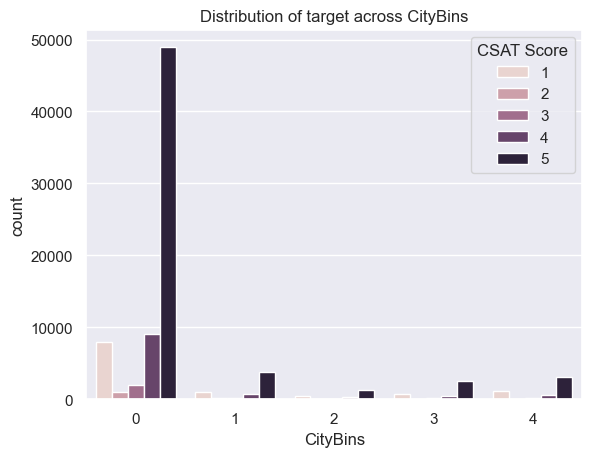

In [142]:
# import seaborn as sns
# import matplotlib.pyplot as plt

sns.countplot(data=data, x="CityBins", hue=target)
plt.title("Distribution of target across CityBins")
plt.show()


In [143]:
grouped = data.groupby("CityBins")[target]

print("Mean CSAT score for each CityBin")
print(grouped.mean())

print("\nMedian (50th percentile) CSAT score for each CityBin")
print(grouped.quantile(0.50))

print("\n25th percentile CSAT score for each CityBin")
print(grouped.quantile(0.25))




Mean CSAT score for each CityBin
CityBins
0    4.310658
1    4.041880
2    4.026756
3    4.004788
4    3.826045
Name: CSAT Score, dtype: float64

Median (50th percentile) CSAT score for each CityBin
CityBins
0    5.0
1    5.0
2    5.0
3    5.0
4    5.0
Name: CSAT Score, dtype: float64

25th percentile CSAT score for each CityBin
CityBins
0    4.0
1    4.0
2    4.0
3    4.0
4    3.0
Name: CSAT Score, dtype: float64


In [144]:
# Checking the normality of CSAT Scores within each citybin

from scipy.stats import shapiro

for bin_val in data['CityBins'].unique():
    scores = data.loc[data['CityBins'] == bin_val, 'CSAT Score']
    stat, p_val = shapiro(scores)
    print(f"CityBin {bin_val}: W-stat={stat:.3f}, p-value={p_val:.3f}")
    
    if p_val > 0.05:
        print("   ✅ Data looks normal (fail to reject H0)")
    else:
        print("   ⚠️ Data not normal (reject H0)")


CityBin 0: W-stat=0.562, p-value=0.000
   ⚠️ Data not normal (reject H0)
CityBin 3: W-stat=0.628, p-value=0.000
   ⚠️ Data not normal (reject H0)
CityBin 2: W-stat=0.631, p-value=0.000
   ⚠️ Data not normal (reject H0)
CityBin 4: W-stat=0.663, p-value=0.000
   ⚠️ Data not normal (reject H0)
CityBin 1: W-stat=0.630, p-value=0.000
   ⚠️ Data not normal (reject H0)


Since CSAT score is not normal within any of the CityBins -> we will use non parametric tests rather than parametric tests for checking the relationship presence between CityBins and CSAT Score

In [145]:
# the records where csat score is 4 
csat_4_records = data[data[target] == 4]
# get the customer remarks as list where customer remarks is not null
customer_remarks_4 = csat_4_records[csat_4_records['Customer Remarks'].notna()]['Customer Remarks'].tolist()
customer_remarks_4[:10]

['Very good ',
 'Please pack the products which actually customers ordered, otherwise it is time to both you and us Shopzilla.',
 'Nice ',
 "My issue is not resolved from yesterday.this is not a good thing.if customer issue is not solved quickly then why we don't do shopping from other shopping app where our issue is solved quickly ",
 'Very nice ',
 'Bot is very annoying',
 'Item are too delay of delivery date',
 "Problems and concern's Good Understanding and solved.",
 'U cal display ur customers support number4 help any customers problem But no display customers care number',
 'Happy']

In [146]:
customer_remarks_4[:20]

['Very good ',
 'Please pack the products which actually customers ordered, otherwise it is time to both you and us Shopzilla.',
 'Nice ',
 "My issue is not resolved from yesterday.this is not a good thing.if customer issue is not solved quickly then why we don't do shopping from other shopping app where our issue is solved quickly ",
 'Very nice ',
 'Bot is very annoying',
 'Item are too delay of delivery date',
 "Problems and concern's Good Understanding and solved.",
 'U cal display ur customers support number4 help any customers problem But no display customers care number',
 'Happy',
 'Over all very good ',
 'Good ',
 'It will be good, if the customer support had a first hand information and provide to the customer immediately.',
 'Very good ',
 'Our return request are getting auto canceled three times.  Please avoid this refund the amount.',
 'Return request was done by me but your delivery partner was not picked up the order, and my request of return was automatically cancelled 

In [147]:
# Percentages of each CSAT class within each CityBin
pd.crosstab(data["CityBins"], data["CSAT Score"], normalize="index")

CSAT Score,1,2,3,4,5
CityBins,,,,,
0,0.114605,0.013817,0.028927,0.131618,0.711033
1,0.174530,0.020513,0.032821,0.132821,0.639316
2,0.178691,0.021978,0.028189,0.136168,0.634974
3,0.189768,0.018649,0.030998,0.118196,0.642389
4,0.231037,0.017802,0.037345,0.121711,0.592105


In [148]:
# check missingness in csat and citybins
print("Missing values in CSAT Score:", data["CSAT Score"].isnull().sum())
print("Missing values in CityBins:", data["CityBins"].isnull().sum())

Missing values in CSAT Score: 0
Missing values in CityBins: 0


In [149]:
# Kruskal wallis Test for checking the relationship presence : Since CSAT score not normal within each citybin 
# DO CSAT scores differ significantly across CityBins?

# Group CSAT scores by CityBin
groups = [data.loc[data['CityBins'] == bin_val, 'CSAT Score'] 
          for bin_val in data['CityBins'].unique()]

from scipy.stats import kruskal

# Perform Kruskal-Wallis test
h_stat, p_val = kruskal(*groups)

print("H-statistic:", h_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("✅ Significant difference in CSAT across CityBins (non-parametric)")
else:
    print("❌ No significant difference across CityBins")


H-statistic: 687.7475597611036
p-value: 1.5673828975767002e-147
✅ Significant difference in CSAT across CityBins (non-parametric)



FEATURE_NAME                           ||||         MISSING_PERCENT           |||||                 UNIQUE_VAL   
Customer_City                          ||||           80.12                   |||||                   1782     
connected_handling_time                ||||           99.72                   |||||                    211     
Product_category                       ||||           79.98                   |||||                      9     
Item_price                             ||||           79.97                   |||||                   2789    
order_date_time                        ||||           79.96                   |||||                  13766     
Customer Remarks                       ||||           66.54                   |||||                  18231     
Order_id                               ||||           21.22                   |||||                  67675    




Customer_City processing done

Connected_handling_time

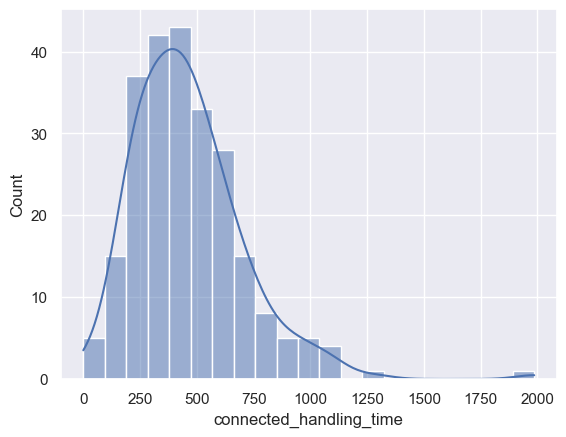

In [150]:
feature = "connected_handling_time"

sns.histplot(data[feature] , kde = True)
plt.show()

Right skewness in the distribution - Peak around 350 seconds(5-6 mins)

In [151]:
data['connectedTime_MI']  = data[feature].isna().astype(int)

Does connected_handling_time have any relationship with CSAT score ?

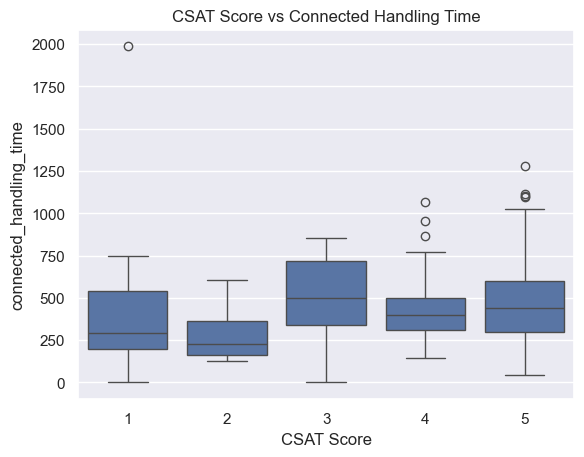

In [152]:
# Boxplot of CSAT Score vs Connected Handling Time (only for non-missing values)
temp = data[[feature, target]].dropna()
sns.boxplot(x=target, y=feature, data=temp)
plt.title("CSAT Score vs Connected Handling Time")
plt.show()

The median connected handling time is higher for higher CSAT scores. 1 and 2 csat scores have comparatively lower connected handliing time than 3, 4, 5 csat scores.

In [153]:
# check if handling time is normal within each csat score level
for csat_val in data[target].unique():
    scores = data.loc[data[target] == csat_val, feature].dropna()
    stat, p_val = shapiro(scores)
    print(f"CSAT Score {csat_val}: W-stat={stat:.3f}, p-value={p_val:.3f}")
    
    if p_val > 0.05:
        print("   ✅ Data looks normal (fail to reject H0)")
    else:
        print("   ⚠️ Data not normal (reject H0)")

CSAT Score 5: W-stat=0.959, p-value=0.000
   ⚠️ Data not normal (reject H0)
CSAT Score 4: W-stat=0.859, p-value=0.001
   ⚠️ Data not normal (reject H0)
CSAT Score 1: W-stat=0.707, p-value=0.000
   ⚠️ Data not normal (reject H0)
CSAT Score 3: W-stat=0.963, p-value=0.844
   ✅ Data looks normal (fail to reject H0)
CSAT Score 2: W-stat=0.866, p-value=0.281
   ✅ Data looks normal (fail to reject H0)


In [154]:
# Do handling-time distributions differ across CSAT levels? - kruskal wallis test 
groups = [
    data.loc[data['CSAT Score'] == score, feature].dropna()
    for score in sorted(data['CSAT Score'].dropna().unique())
]

# from scipy.stats import kruskal

h, p = kruskal(*groups)

print(h, p)
if p < 0.05:
    print("✅ Significant difference in handling time across CSAT levels")
else:
    print("❌ No significant difference in handling time across CSAT levels")

5.689206684448023 0.22359186807142298
❌ No significant difference in handling time across CSAT levels


In [155]:
# As handling time increases, does CSAT tend to increase or decrease? 
from scipy.stats import spearmanr

corr, p = spearmanr(
    temp[feature],
    temp[target]
)

print(corr, p)



0.11376691910193046 0.07733315515447751


Spearmann correlation shows weak monotonic relationship between connected handling time and csat score.

In [156]:
# calculating different quantiles of connected_handling_time and printing them
print("Quantiles of Connected Handling Time:")
quantiles = np.percentile(temp[feature], [25, 50, 75, 85, 90, 95, 99])
print(f"25th percentile: {quantiles[0]:.2f} seconds")
print(f"50th percentile (median): {quantiles[1]:.2f} seconds")
print(f"75th percentile: {quantiles[2]:.2f} seconds")
print(f"85th percentile: {quantiles[3]:.2f} seconds")
print(f"90th percentile: {quantiles[4]:.2f} seconds")
print(f"95th percentile: {quantiles[5]:.2f} seconds")
print(f"99th percentile: {quantiles[6]:.2f} seconds")


Quantiles of Connected Handling Time:
25th percentile: 293.00 seconds
50th percentile (median): 427.00 seconds
75th percentile: 592.25 seconds
85th percentile: 681.50 seconds
90th percentile: 753.20 seconds
95th percentile: 915.75 seconds
99th percentile: 1108.85 seconds


In [157]:
# connectedtime Bins < 250 , <500 , <750 , <1000 , >1000 , nan

def connectedTimebins(time):
    # if time is nan return 0
    if pd.isna(time):
        return 0
    if time <= 293:
        return 1 
    elif time <= 427:
        return 2
    elif time <= 592:
        return 3
    elif time <= 915:
        return 4
    elif time > 915:
        return 5


data["ConnectedTimeBins"] = data[feature].apply(connectedTimebins)



In [158]:
# checking missing values in connected time bins
print("Missing values in ConnectedTimeBins:", data["ConnectedTimeBins"].isnull().sum())

Missing values in ConnectedTimeBins: 0


In [159]:
connectedTimebins_scaler = StandardScaler()
data["connectedTimeBins_normalized"] = connectedTimebins_scaler.fit_transform(data[["ConnectedTimeBins"]])

In [160]:
joblib.dump(connectedTimebins_scaler , f"{PREPROCESS_DIR}/connectedTimebins_scaler.joblib")

['../data_analysis1/artifacts/preprocess/connectedTimebins_scaler.joblib']

In [161]:
data.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'City_MI', 'CityBins', 'CityBins_normalized',
       'connectedTime_MI', 'ConnectedTimeBins',
       'connectedTimeBins_normalized'],
      dtype='object')

Checking the relation between ConnectedTimeBins and target



In [162]:
# Checking the normality of CSAT in each bin

from scipy.stats import shapiro

for bin_val in data['ConnectedTimeBins'].unique():
    scores = data.loc[data['ConnectedTimeBins'] == bin_val, 'CSAT Score']
    stat, p_val = shapiro(scores)
    print(f"CityBin {bin_val}: W-stat={stat:.3f}, p-value={p_val:.3f}")
    
    if p_val > 0.05:
        print("   ✅ Data looks normal (fail to reject H0)")
    else:
        print("   ⚠️ Data not normal (reject H0)")

CityBin 0: W-stat=0.580, p-value=0.000
   ⚠️ Data not normal (reject H0)
CityBin 1: W-stat=0.585, p-value=0.000
   ⚠️ Data not normal (reject H0)
CityBin 2: W-stat=0.531, p-value=0.000
   ⚠️ Data not normal (reject H0)
CityBin 3: W-stat=0.460, p-value=0.000
   ⚠️ Data not normal (reject H0)
CityBin 4: W-stat=0.442, p-value=0.000
   ⚠️ Data not normal (reject H0)
CityBin 5: W-stat=0.485, p-value=0.000
   ⚠️ Data not normal (reject H0)


In [163]:
# Kruskal test to check the relation strength - Whether CSAT scores differ significantly across ConnectedTimeBins

from scipy.stats import kruskal

groups = [data.loc[data['ConnectedTimeBins'] == bin_val, 'CSAT Score'] 
          for bin_val in data['ConnectedTimeBins'].unique()]

# Perform Kruskal-Wallis test
h_stat, p_val = kruskal(*groups)

print("H-statistic:", h_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("✅ Significant difference in CSAT across ConnectedTimeBins (non-parametric)")
else:
    print("❌ No significant difference across ConnectedTimeBins")


H-statistic: 9.13709024942486
p-value: 0.10371944825807483
❌ No significant difference across ConnectedTimeBins


 In isolation the ConnectedTimeBins seems to be a weak predictor , but in association with Missing Indicatory feature and other available features , it may provide some positive predictive power. The feature is kept for now

Product Category Inspection

In [164]:
feature = "Product_category"
feature

'Product_category'

In [165]:
data[feature].value_counts(dropna = False)

Product_category
NaN                            68711
Electronics                     4706
LifeStyle                       4118
Books & General merchandise     3323
Mobile                          1758
Home                            1328
Home Appliences                 1300
Furniture                        471
Affiliates                       166
GiftCard                          26
Name: count, dtype: int64

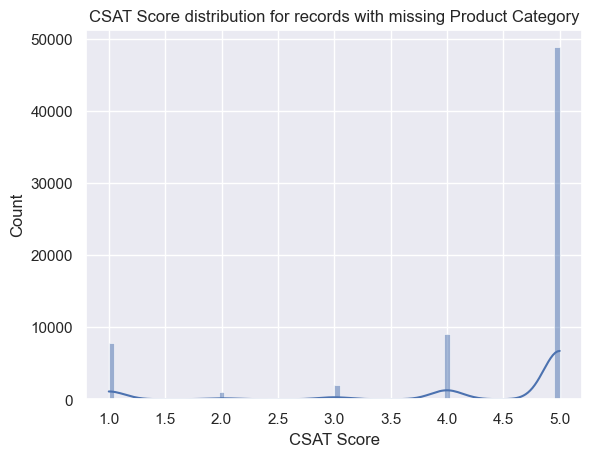

In [166]:
sns.histplot(data.loc[data[feature].isna() , 'CSAT Score'] , kde = True)
plt.title("CSAT Score distribution for records with missing Product Category")
plt.show()

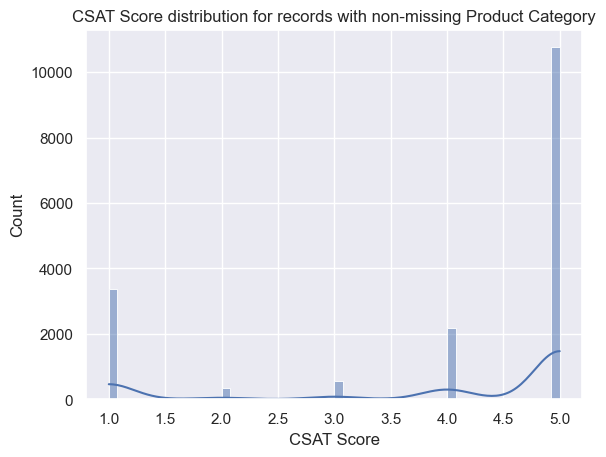

In [167]:
sns.histplot(data.loc[data[feature].notna() , 'CSAT Score'] , kde = True)
plt.title("CSAT Score distribution for records with non-missing Product Category")
plt.show()

In [168]:
data["Product_cat_MI"] = data[feature].isna().astype(int)


In [169]:
data[feature].nunique()

9

In [170]:
feature

'Product_category'

In [171]:
# Chi Square test of independence to check the relation strength between Product Category and target

import pandas as pd
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(data[feature], data[target])

# Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi2 statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

if p < 0.05:
    print("✅ Significant association between predictor and target")
else:
    print("❌ No significant association between predictor and target")


Chi2 statistic: 224.29675164907758
p-value: 9.697459153266958e-31
Degrees of freedom: 32
✅ Significant association between predictor and target


In [172]:
data[feature] = data[feature].fillna("Unknown")

In [173]:
data[feature].nunique()

10

In [174]:
# Chi Square test of independence to check the relation strength between feature and target

import pandas as pd
from scipy.stats import chi2_contingency

# Create a contingency table
contingency_table = pd.crosstab(data[feature], data[target])

# Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi2 statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

if p < 0.05:
    print("✅ Significant association between predictor and target")
else:
    print("❌ No significant association between predictor and target")


Chi2 statistic: 1182.162361600318
p-value: 7.521233209340669e-225
Degrees of freedom: 36
✅ Significant association between predictor and target


In [175]:
# Checking the relationship using kruskal wallis test - whether csat scores differ significantly across product categories
groups = [data.loc[data[feature] == cat, 'CSAT Score'] 
          for cat in data[feature].unique()] 
h_stat, p_val = kruskal(*groups)
print("H-statistic:", h_stat)
print("p-value:", p_val)
if p_val < 0.05:
    print("✅ Significant difference in CSAT across product categories (non-parametric)")
else:
    print("❌ No significant difference in CSAT across product categories (non-parametric)")

H-statistic: 773.3052249895759
p-value: 1.1825565189875012e-160
✅ Significant difference in CSAT across product categories (non-parametric)


In [53]:
from sklearn.preprocessing import OneHotEncoder
product_ohe = OneHotEncoder(drop = 'first' , sparse_output = False)
ohe_product_categories = product_ohe.fit_transform(data[[feature]])

In [54]:
import joblib
joblib.dump(product_ohe , f"{PREPROCESS_DIR}/product_ohe.joblib")

['../data_analysis1/artifacts/preprocess/product_ohe.joblib']

In [55]:
ohe_product_categories

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(85907, 9))

In [56]:
product_ohe.categories_

[array(['Affiliates', 'Books & General merchandise', 'Electronics',
        'Furniture', 'GiftCard', 'Home', 'Home Appliences', 'LifeStyle',
        'Mobile', 'Unknown'], dtype=object)]

In [57]:
data.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'City_MI', 'CityBins', 'CityBins_normalized',
       'connectedTime_MI', 'ConnectedTimeBins', 'connectedTimeBins_normalized',
       'Product_cat_MI'],
      dtype='object')

In [58]:
data_matrix = data.loc[:,['City_MI', 'CityBins_normalized', 'connectedTime_MI',
       'connectedTimeBins_normalized', 'Product_cat_MI' , ]].to_numpy()
data_matrix

array([[1.        , 0.32002832, 1.        , 0.05143005, 1.        ],
       [1.        , 0.32002832, 1.        , 0.05143005, 1.        ],
       [1.        , 0.32002832, 1.        , 0.05143005, 1.        ],
       ...,
       [1.        , 0.32002832, 1.        , 0.05143005, 1.        ],
       [1.        , 0.32002832, 1.        , 0.05143005, 1.        ],
       [1.        , 0.32002832, 1.        , 0.05143005, 1.        ]],
      shape=(85907, 5))

In [59]:
data_matrix.shape , ohe_product_categories.shape

((85907, 5), (85907, 9))

In [60]:
type(data_matrix) , type(ohe_product_categories)

(numpy.ndarray, numpy.ndarray)

In [61]:
data_matrix = np.concatenate([data_matrix , ohe_product_categories],axis = 1)

In [176]:
feature = "Item_price"
data[feature].isna().sum()/len(data)



np.float64(0.7997136438241355)

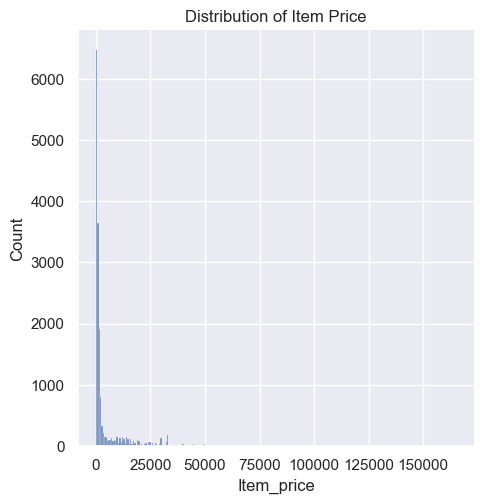

In [178]:
sns.displot(data[feature])
plt.title("Distribution of Item Price")
plt.show()

In [179]:
data['Price_MI'] = data[feature].isna().astype(int)

In [180]:
np.nanmean(data[feature])

np.float64(5660.7748459839595)

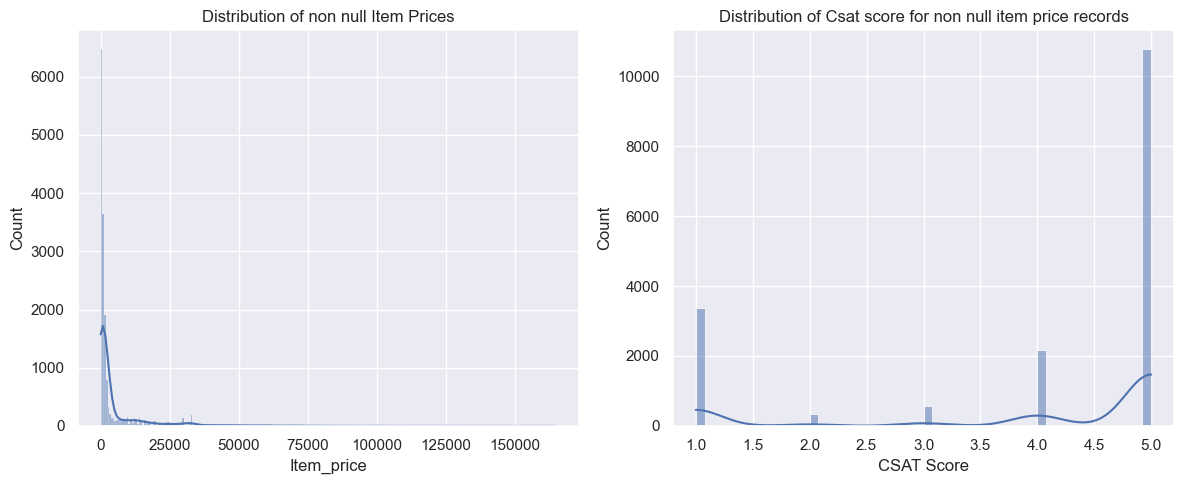

In [66]:
plt.figure(figsize = (12,5))

plt.subplot(1,2 , 1)
sns.histplot(data.loc[data[feature].notna(),feature] , kde = True)
plt.title("Distribution of non null Item Prices")



plt.subplot(1,2,2)
sns.histplot(data.loc[data[feature].notna(),target], kde = True)
plt.title("Distribution of Csat score for non null item price records")
            
plt.tight_layout()
plt.show()

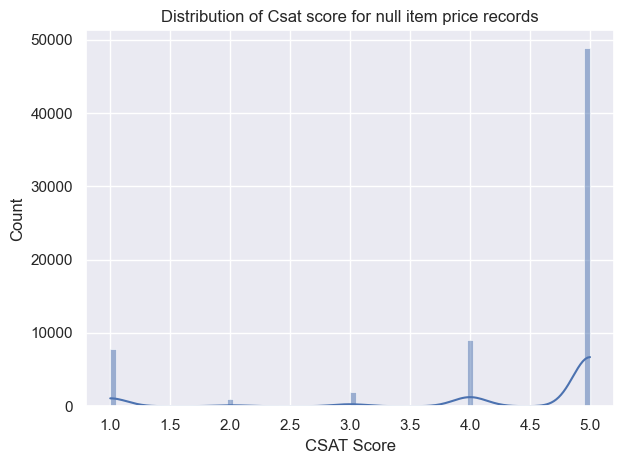

In [67]:

sns.histplot(data.loc[data[feature].isna(),target], kde = True)
plt.title("Distribution of Csat score for null item price records")
            
plt.tight_layout()
plt.show()

Distribution looks more or less similar for target variable for null Item Price and Non null Item Price.

High Right Skewness in Item Prices

In [69]:
not_na_Item_price = data.loc[data[feature].notna() , feature].values
not_na_Item_price

array([  434.,  1299., 15990., ...,   998.,   193., 23999.],
      shape=(17206,))

In [70]:
np.set_printoptions(suppress=True)

In [71]:
sorted_arr  = np.sort(not_na_Item_price)
numbers , counts = np.unique(sorted_arr , return_counts = True)
missing_no = data[feature].isna().sum()

In [72]:
counts = counts/np.sum(counts)
counts

array([0.00005812, 0.00092991, 0.00011624, ..., 0.00005812, 0.00005812,
       0.00005812], shape=(2789,))

In [73]:
numbers.shape , counts.shape

((2789,), (2789,))

In [74]:
price_low_lim  = np.min(numbers)
price_high_lim = np.max(numbers)


price_limits = {
    "low": price_low_lim,
    "high": price_high_lim
}

joblib.dump(price_limits, f"{PREPROCESS_DIR}/price_limits.joblib")

['../data_analysis1/artifacts/preprocess/price_limits.joblib']

In [75]:
impute_prices = np.random.choice(numbers , size = missing_no  , replace = True ,p = counts)
impute_prices

array([2810.,  549., 3299., ...,  999., 7499.,  454.], shape=(68701,))

In [76]:
impute_indices = data[data[feature].isna()].index
impute_indices

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       85895, 85896, 85897, 85898, 85899, 85902, 85903, 85904, 85905, 85906],
      dtype='int64', length=68701)

In [77]:
impute_prices = pd.Series(impute_prices , index = impute_indices)

data[feature] = data[feature].fillna(impute_prices)

<Axes: xlabel='Item_price', ylabel='Count'>

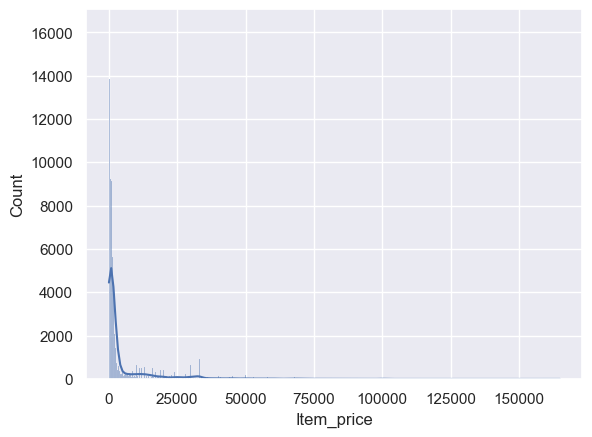

In [78]:
sns.histplot(data[feature] , kde = True)

In [79]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
data['Item_Price_normalized'] = pt.fit_transform(data[[feature]])

In [80]:
joblib.dump(pt , f"{PREPROCESS_DIR}/price_transformer.joblib")

['../data_analysis1/artifacts/preprocess/price_transformer.joblib']

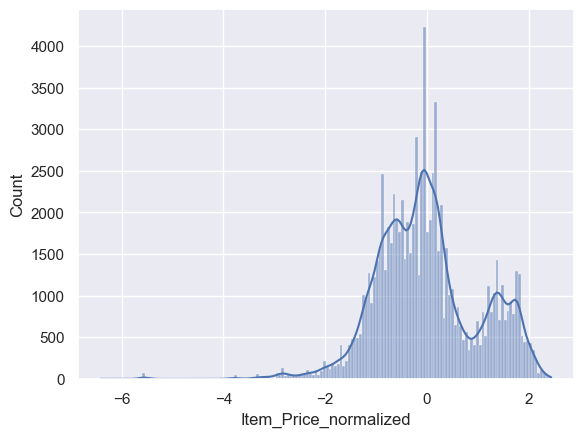

In [81]:
sns.histplot(data['Item_Price_normalized'] , kde = True)
plt.show()

In [82]:
data["Item_Price_normalized"].skew()

np.float64(-0.01864776775530631)

In [83]:
data_matrix = np.concatenate([data_matrix , data[['Item_Price_normalized']].values],axis = 1)

In [84]:
data.shape

(85907, 29)

In [85]:
data.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'City_MI', 'CityBins', 'CityBins_normalized',
       'connectedTime_MI', 'ConnectedTimeBins', 'connectedTimeBins_normalized',
       'Product_cat_MI', 'Price_MI', 'Item_Price_normalized'],
      dtype='object')

In [86]:
data.isnull().mean().sort_values(ascending=False)

connected_handling_time         0.997183
Customer_City                   0.801192
order_date_time                 0.799621
Customer Remarks                0.665429
Order_id                        0.212230
Sub-category                    0.000000
category                        0.000000
channel_name                    0.000000
Issue_reported at               0.000000
issue_responded                 0.000000
Survey_response_Date            0.000000
Product_category                0.000000
Unique id                       0.000000
Item_price                      0.000000
Agent_name                      0.000000
Supervisor                      0.000000
Manager                         0.000000
Tenure Bucket                   0.000000
Agent Shift                     0.000000
CSAT Score                      0.000000
City_MI                         0.000000
CityBins                        0.000000
CityBins_normalized             0.000000
connectedTime_MI                0.000000
ConnectedTimeBin

In [87]:
# Order_id column check.Whether there are duplication in this column . If yes , it would mean that more than one record corresponding to a single order resolution.
print(data['Order_id'].duplicated().sum())
# The number of duplication entries coming are equal to the number of null values in the column . Could this be referring nan values in the column as duplicates ?
all_order_id = data['Order_id'].dropna()
print(all_order_id.duplicated().sum())
# It was indeed referring to the NaN values in the column as duplicates.
# Other than that, there are no duplicate entries in the Order_id column.
# This mean order id is also a unique record idenfier column for this dataset.
# We will be dropping this column.


18231
0


In [88]:
data.drop(['Order_id' , 'Unique id'] , axis = 1 , inplace = True)

In [89]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score', 'City_MI',
       'CityBins', 'CityBins_normalized', 'connectedTime_MI',
       'ConnectedTimeBins', 'connectedTimeBins_normalized', 'Product_cat_MI',
       'Price_MI', 'Item_Price_normalized'],
      dtype='object')

Preprocessing of Customer Remarks

In [90]:
feature = "Customer Remarks"

In [91]:
data[feature]

0                                             NaN
1                                             NaN
2                                             NaN
3                                             NaN
4                                             NaN
                           ...                   
85902                                         NaN
85903    Supported team customer executive   good
85904        need to improve with proper details.
85905                                         NaN
85906                                         NaN
Name: Customer Remarks, Length: 85907, dtype: object

In [92]:
data['Remarks_MI'] = data[feature].isna().astype(int)

In [93]:
data_matrix = np.concatenate([data_matrix , data[["Remarks_MI"]].values] , axis  = 1)

In [94]:
from textblob import TextBlob

def get_sentiment(text):
    if pd.isna(text):
        return 0.0
    else:
        return TextBlob(str(text)).sentiment.polarity

data["Remarks_sentiment"] = data[feature].apply(get_sentiment)


In [95]:
data_matrix = np.concatenate([data_matrix , data[['Remarks_sentiment']].values] , axis = 1)

In [96]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score', 'City_MI',
       'CityBins', 'CityBins_normalized', 'connectedTime_MI',
       'ConnectedTimeBins', 'connectedTimeBins_normalized', 'Product_cat_MI',
       'Price_MI', 'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment'],
      dtype='object')

In [97]:
data[feature]

0                                             NaN
1                                             NaN
2                                             NaN
3                                             NaN
4                                             NaN
                           ...                   
85902                                         NaN
85903    Supported team customer executive   good
85904        need to improve with proper details.
85905                                         NaN
85906                                         NaN
Name: Customer Remarks, Length: 85907, dtype: object

In [98]:
def remark_word_count(text):
    if pd.isna(text):
        return 0
    else:
        word_count = len(text.split(" "))
        return word_count
    


data['Remark_word_count'] = data[feature].apply(remark_word_count)

In [99]:
from sklearn.preprocessing import StandardScaler
remark_word_count_scaler = StandardScaler()

data['Remark_word_count'] = remark_word_count_scaler.fit_transform(data[["Remark_word_count"]])

In [100]:
joblib.dump(remark_word_count_scaler , f"{PREPROCESS_DIR}/remark_word_count_scaler.joblib")

['../data_analysis1/artifacts/preprocess/remark_word_count_scaler.joblib']

In [101]:
data_matrix = np.concatenate([data_matrix , data[['Remark_word_count']].values] , axis = 1)

In [102]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'Customer Remarks',
       'order_date_time', 'Issue_reported at', 'issue_responded',
       'Survey_response_Date', 'Customer_City', 'Product_category',
       'Item_price', 'connected_handling_time', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score', 'City_MI',
       'CityBins', 'CityBins_normalized', 'connectedTime_MI',
       'ConnectedTimeBins', 'connectedTimeBins_normalized', 'Product_cat_MI',
       'Price_MI', 'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count'],
      dtype='object')

In [103]:
data.drop(['Survey_response_Date'] , axis = 1 , inplace = True)

In [104]:
data.isna().sum()

channel_name                        0
category                            0
Sub-category                        0
Customer Remarks                57165
order_date_time                 68693
Issue_reported at                   0
issue_responded                     0
Customer_City                   68828
Product_category                    0
Item_price                          0
connected_handling_time         85665
Agent_name                          0
Supervisor                          0
Manager                             0
Tenure Bucket                       0
Agent Shift                         0
CSAT Score                          0
City_MI                             0
CityBins                            0
CityBins_normalized                 0
connectedTime_MI                    0
ConnectedTimeBins                   0
connectedTimeBins_normalized        0
Product_cat_MI                      0
Price_MI                            0
Item_Price_normalized               0
Remarks_MI  

In [105]:
data.shape

(85907, 29)

In [106]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   channel_name                  85907 non-null  object 
 1   category                      85907 non-null  object 
 2   Sub-category                  85907 non-null  object 
 3   Customer Remarks              28742 non-null  object 
 4   order_date_time               17214 non-null  object 
 5   Issue_reported at             85907 non-null  object 
 6   issue_responded               85907 non-null  object 
 7   Customer_City                 17079 non-null  object 
 8   Product_category              85907 non-null  object 
 9   Item_price                    85907 non-null  float64
 10  connected_handling_time       242 non-null    float64
 11  Agent_name                    85907 non-null  object 
 12  Supervisor                    85907 non-null  object 
 13  M

In [107]:
data.describe()

,Item_price,connected_handling_time,CSAT Score,City_MI,CityBins,CityBins_normalized,connectedTime_MI,ConnectedTimeBins,connectedTimeBins_normalized,Product_cat_MI,Price_MI,Item_Price_normalized,Remarks_MI,Remarks_sentiment,Remark_word_count
count,85907.000000,242.000000,85907.000000,85907.000000,85907.000000,8.590700e+04,85907.000000,85907.000000,8.590700e+04,85907.00000,85907.000000,8.590700e+04,85907.000000,85907.000000,8.590700e+04
mean,5591.530399,462.400826,4.242157,0.801192,4.724097,4.234787e-17,0.997183,5.989628,1.222795e-15,0.79983,0.799714,-1.773317e-16,0.665429,0.097058,-1.191034e-17
std,12563.962162,246.295037,1.378903,0.399106,0.862126,1.000006e+00,0.053001,0.201667,1.000006e+00,0.40013,0.400217,1.000006e+00,0.471843,0.290414,1.000006e+00
min,0.000000,0.000000,1.000000,0.000000,1.000000,-4.319694e+00,0.000000,1.000000,-2.474207e+01,0.00000,0.000000,-6.419118e+00,0.000000,-1.000000,-3.066808e-01
25%,393.000000,293.000000,4.000000,1.000000,5.000000,3.200283e-01,1.000000,6.000000,5.143005e-02,1.00000,1.000000,-6.663138e-01,0.000000,0.000000,-3.066808e-01
50%,988.000000,427.000000,5.000000,1.000000,5.000000,3.200283e-01,1.000000,6.000000,5.143005e-02,1.00000,1.000000,-5.720808e-02,1.000000,0.000000,-3.066808e-01
75%,2699.000000,592.250000,5.000000,1.000000,5.000000,3.200283e-01,1.000000,6.000000,5.143005e-02,1.00000,1.000000,5.441599e-01,1.000000,0.000000,-8.238484e-02
max,164999.000000,1986.000000,5.000000,1.000000,5.000000,3.200283e-01,1.000000,6.000000,5.143005e-02,1.00000,1.000000,2.444587e+00,1.000000,1.000000,5.150569e+01


In [108]:
# show all features of data irrespective of their number
pd.set_option('display.max_columns', None)

In [109]:
data.isnull().sum()

channel_name                        0
category                            0
Sub-category                        0
Customer Remarks                57165
order_date_time                 68693
Issue_reported at                   0
issue_responded                     0
Customer_City                   68828
Product_category                    0
Item_price                          0
connected_handling_time         85665
Agent_name                          0
Supervisor                          0
Manager                             0
Tenure Bucket                       0
Agent Shift                         0
CSAT Score                          0
City_MI                             0
CityBins                            0
CityBins_normalized                 0
connectedTime_MI                    0
ConnectedTimeBins                   0
connectedTimeBins_normalized        0
Product_cat_MI                      0
Price_MI                            0
Item_Price_normalized               0
Remarks_MI  

In [110]:
data.drop(['Customer Remarks' , 'Customer_City' , 'connected_handling_time'] , axis = 1, inplace = True)

In [111]:
data.isnull().sum()

channel_name                        0
category                            0
Sub-category                        0
order_date_time                 68693
Issue_reported at                   0
issue_responded                     0
Product_category                    0
Item_price                          0
Agent_name                          0
Supervisor                          0
Manager                             0
Tenure Bucket                       0
Agent Shift                         0
CSAT Score                          0
City_MI                             0
CityBins                            0
CityBins_normalized                 0
connectedTime_MI                    0
ConnectedTimeBins                   0
connectedTimeBins_normalized        0
Product_cat_MI                      0
Price_MI                            0
Item_Price_normalized               0
Remarks_MI                          0
Remarks_sentiment                   0
Remark_word_count                   0
dtype: int64

In [112]:
data.nunique()

channel_name                        3
category                           12
Sub-category                       57
order_date_time                 13766
Issue_reported at               30923
issue_responded                 30262
Product_category                   10
Item_price                       2789
Agent_name                       1371
Supervisor                         40
Manager                             6
Tenure Bucket                       5
Agent Shift                         5
CSAT Score                          5
City_MI                             2
CityBins                            5
CityBins_normalized                 5
connectedTime_MI                    2
ConnectedTimeBins                   6
connectedTimeBins_normalized        6
Product_cat_MI                      2
Price_MI                            2
Item_Price_normalized            2789
Remarks_MI                          2
Remarks_sentiment                1322
Remark_word_count                 163
dtype: int64

In [113]:
# data.drop(["Unique id" , "Order_id"],axis = 1 , inplace = True)

In [114]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'order_date_time',
       'Issue_reported at', 'issue_responded', 'Product_category',
       'Item_price', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket',
       'Agent Shift', 'CSAT Score', 'City_MI', 'CityBins',
       'CityBins_normalized', 'connectedTime_MI', 'ConnectedTimeBins',
       'connectedTimeBins_normalized', 'Product_cat_MI', 'Price_MI',
       'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count'],
      dtype='object')

In [115]:
# channel_name column analysis and preprocessing

data['channel_name'].isna().sum()

np.int64(0)

In [116]:
# channels = data['channel_name'].unique()
# unique_values['channel_name'] = channels

Basic Frequency Analysis

Channel Distribution:
Counts:
channel_name
Inbound    68142
Outcall    14742
Email       3023
Name: count, dtype: int64
Proportions:
channel_name
Inbound    0.793207
Outcall    0.171604
Email      0.035189
Name: proportion, dtype: float64


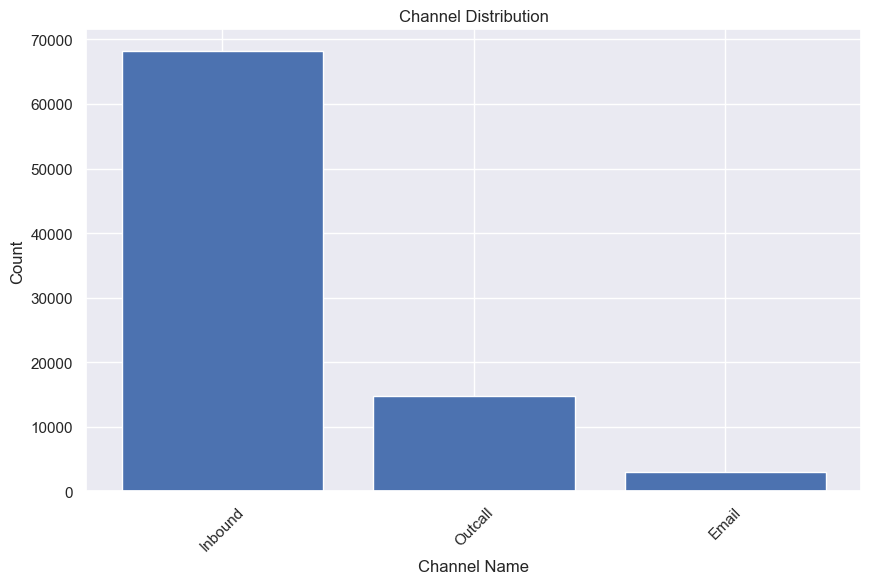

In [117]:
# Get value counts and proportions
channel_counts = data['channel_name'].value_counts()
channel_proportions = data['channel_name'].value_counts(normalize=True)

print("Channel Distribution:")
print(f"Counts:\n{channel_counts}")
print(f"Proportions:\n{channel_proportions}")


# 3 categories in the channel_name column namely Inbound , Outcall and Email.
# Inbound refers to the incoming customer interactions, Outcall refers to the outgoing interactions initiated by the support team, and Email refers to the interactions that happen over email.

# Code to visualize the channel distribution
plt.figure(figsize=(10, 6))
plt.bar(channel_counts.index, channel_counts.values)
plt.title("Channel Distribution")
plt.xlabel("Channel Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Channel-Csat relationship Analysis

In [118]:
# Cross-tabulation analysis
channel_csat_crosstab = pd.crosstab(data['channel_name'], data['CSAT Score'])
print("Channel vs CSAT Score Cross-tabulation:")
print(channel_csat_crosstab)

# Calculate CSAT statistics by channel
channel_csat_stats = data.groupby('channel_name')['CSAT Score'].agg(['mean', 'std', 'count'])
print("CSAT Statistics by Channel:")
print(channel_csat_stats)


Channel vs CSAT Score Cross-tabulation:
CSAT Score       1     2     3     4      5
channel_name                               
Email          636    64   102   388   1833
Inbound       8745  1011  2033  8934  47419
Outcall       1849   208   423  1897  10365
CSAT Statistics by Channel:
                  mean       std  count
channel_name                           
Email         3.899107  1.615222   3023
Inbound       4.251372  1.370008  68142
Outcall       4.269909  1.358055  14742


In [119]:
from scipy.stats import chi2_contingency, f_oneway

# Chi-square test for independence
chi2, p_value, dof, expected = chi2_contingency(channel_csat_crosstab)
print(f"Chi-square test p-value: {p_value}")

# ANOVA test for mean differences across channels
channel_groups = [data[data['channel_name'] == channel]['CSAT Score']
                  for channel in data['channel_name'].unique()]
f_stat, anova_p = f_oneway(*channel_groups)
print(f"ANOVA test p-value: {anova_p}")


Chi-square test p-value: 6.669001520780051e-39
ANOVA test p-value: 2.3194399795949356e-43


chi2 pval < 0.05 , therefore Null Hypothesis failed :
Based on the Chi square test of independence , there is significant relationship between the channel_name and the csat_score.

anova pval < 0.05 , therefore :
Based on the One way anova test ,the mean of the csat score for atleast one of the channels in significantly different from other channel_name.

In [120]:
# One-hot encoding for channel_name
# channel_encoded = pd.get_dummies(data['channel_name'], prefix='channel', drop_first=True)
# # data = pd.concat([data, channel_encoded], axis=1)
# channel_encoded  = channel_encoded.astype(int)


from sklearn.preprocessing import OneHotEncoder

channel_ohe = OneHotEncoder(drop="first" , sparse_output = False)

channel_encoded = channel_ohe.fit_transform(data[['channel_name']])

In [121]:
import joblib
joblib.dump(channel_ohe , f"{PREPROCESS_DIR}/channel_ohe.joblib")

['../data_analysis1/artifacts/preprocess/channel_ohe.joblib']

In [122]:
channel_ohe.categories_

[array(['Email', 'Inbound', 'Outcall'], dtype=object)]

In [123]:
channel_encoded

array([[0., 1.],
       [0., 1.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]], shape=(85907, 2))

In [124]:
data_matrix.shape

(85907, 18)

In [125]:
data_matrix = np.concatenate([data_matrix , channel_encoded] , axis = 1)

In [126]:
data.columns

Index(['channel_name', 'category', 'Sub-category', 'order_date_time',
       'Issue_reported at', 'issue_responded', 'Product_category',
       'Item_price', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket',
       'Agent Shift', 'CSAT Score', 'City_MI', 'CityBins',
       'CityBins_normalized', 'connectedTime_MI', 'ConnectedTimeBins',
       'connectedTimeBins_normalized', 'Product_cat_MI', 'Price_MI',
       'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count'],
      dtype='object')

In [127]:
data.drop(['channel_name'] , axis = 1 , inplace = True)

In [128]:
data.columns

Index(['category', 'Sub-category', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Product_category', 'Item_price', 'Agent_name',
       'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'City_MI', 'CityBins', 'CityBins_normalized', 'connectedTime_MI',
       'ConnectedTimeBins', 'connectedTimeBins_normalized', 'Product_cat_MI',
       'Price_MI', 'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count'],
      dtype='object')

In [129]:
data.isna().sum()

category                            0
Sub-category                        0
order_date_time                 68693
Issue_reported at                   0
issue_responded                     0
Product_category                    0
Item_price                          0
Agent_name                          0
Supervisor                          0
Manager                             0
Tenure Bucket                       0
Agent Shift                         0
CSAT Score                          0
City_MI                             0
CityBins                            0
CityBins_normalized                 0
connectedTime_MI                    0
ConnectedTimeBins                   0
connectedTimeBins_normalized        0
Product_cat_MI                      0
Price_MI                            0
Item_Price_normalized               0
Remarks_MI                          0
Remarks_sentiment                   0
Remark_word_count                   0
dtype: int64

Data analysis and preprocessing of Category Column

In [130]:
feature = 'category'

In [131]:
data['category'].nunique()

12

In [132]:
# Value counts and proportions
category_counts = data['category'].value_counts()
category_props  = data['category'].value_counts(normalize=True)
print(category_counts)
print(category_props)


category
Returns               44097
Order Related         23215
Refund Related         4550
Product Queries        3692
Shopzilla Related      2792
Payments related       2327
Feedback               2294
Cancellation           2212
Offers & Cashback       480
Others                   99
App/website              84
Onboarding related       65
Name: count, dtype: int64
category
Returns               0.513311
Order Related         0.270234
Refund Related        0.052964
Product Queries       0.042977
Shopzilla Related     0.032500
Payments related      0.027087
Feedback              0.026703
Cancellation          0.025749
Offers & Cashback     0.005587
Others                0.001152
App/website           0.000978
Onboarding related    0.000757
Name: proportion, dtype: float64


In [133]:
low_freq_cat = [cat for cat,val in category_props.items() if val < 0.1]
lowest_freq_cat = [cat for cat,val in category_counts.items() if val < 2000]

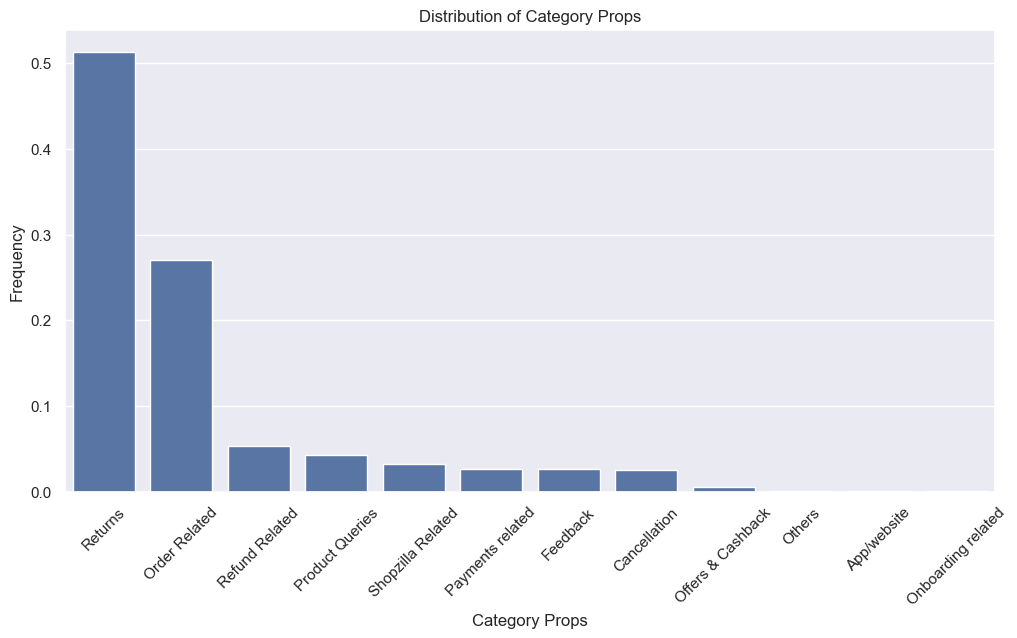

In [134]:
# create the bar chart to visualize the distribution of category_props
plt.figure(figsize=(12,6))
sns.barplot(x=category_props.index, y=category_props.values)
plt.title('Distribution of Category Props')
plt.xlabel('Category Props')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()


In [135]:
# CSAT score distribution across categories

# Crosstab of counts
cat_crosstab = pd.crosstab(data['category'], data['CSAT Score'] , normalize = True)
print(cat_crosstab)

# Mean, Std, Count of CSAT per category
cat_stats = data.groupby('category')['CSAT Score'].agg(['mean','std','count'])
print(cat_stats)


CSAT Score                 1         2         3         4         5
category                                                            
App/website         0.000128  0.000000  0.000000  0.000070  0.000780
Cancellation        0.005064  0.000466  0.000675  0.002992  0.016553
Feedback            0.004086  0.000407  0.000885  0.003131  0.018194
Offers & Cashback   0.000803  0.000023  0.000128  0.000873  0.003760
Onboarding related  0.000105  0.000012  0.000023  0.000058  0.000559
Order Related       0.043419  0.004912  0.009615  0.036633  0.175655
Others              0.000338  0.000047  0.000081  0.000151  0.000535
Payments related    0.002770  0.000407  0.000803  0.003574  0.019533
Product Queries     0.006786  0.001059  0.002084  0.006775  0.026273
Refund Related      0.007194  0.000757  0.001408  0.007089  0.036516
Returns             0.056154  0.006391  0.013200  0.065338  0.372228
Shopzilla Related   0.003876  0.000454  0.000873  0.003911  0.023386
                        mean      

In [136]:
cat_crosstab = pd.crosstab(data['category'], data['CSAT Score'])
# print(cat_crosstab)

In [137]:
a = cat_crosstab[cat_crosstab.index.isin(low_freq_cat)]
a

CSAT Score,1,2,3,4,5
category,,,,,
App/website,11,0,0,6,67
Cancellation,435,40,58,257,1422
Feedback,351,35,76,269,1563
Offers & Cashback,69,2,11,75,323
Onboarding related,9,1,2,5,48
Others,29,4,7,13,46
Payments related,238,35,69,307,1678
Product Queries,583,91,179,582,2257
Refund Related,618,65,121,609,3137


In [138]:
b = cat_crosstab[cat_crosstab.index.isin(lowest_freq_cat)]
b

CSAT Score,1,2,3,4,5
category,,,,,
App/website,11,0,0,6,67
Offers & Cashback,69,2,11,75,323
Onboarding related,9,1,2,5,48
Others,29,4,7,13,46


In [139]:
# Checking for the significant relationship between category and CSAT Score

from scipy.stats import chi2_contingency
chi2, p, _, _ = chi2_contingency(a)
print("Chi² p-value:", p)


Chi² p-value: 2.119064115911417e-37


Significant relationship between category feature and target

In [140]:
from scipy.stats import chi2_contingency
chi2, p, _, _ = chi2_contingency(b)
print("Chi² p-value:", p)

Chi² p-value: 2.7005163657739943e-06


Significant relationship between category feature and target

In [141]:
chi2, p, _, _ = chi2_contingency(cat_crosstab)
print("Chi² p-value:", p)

Chi² p-value: 4.860086707285712e-152


Output of Chi Square test of independence 

Since pval < 0.05 therfore rejecting the null hypothesis :
    There is a statistically significant association between category and csat score

I was trying to check if there is significant variation happening in csat score just for some low frequency categories or not . It was to judge whether or not should i go for aggregating these low frequency categories into a single category or not . But since the variation or effect of them on the target  variable is strongly different from each other , I will avoid doing the aggregation of these categories

Based on the One way anova test also ,the mean of the csat score for atleast one of the categories is significantly different from other categories.

In [142]:
data['category'].isnull().sum()
# no missing values

np.int64(0)

No missing values in categories

In [143]:
data['category'].nunique()

12

In [144]:
data['category'].value_counts()

category
Returns               44097
Order Related         23215
Refund Related         4550
Product Queries        3692
Shopzilla Related      2792
Payments related       2327
Feedback               2294
Cancellation           2212
Offers & Cashback       480
Others                   99
App/website              84
Onboarding related       65
Name: count, dtype: int64

In [145]:
category_ohe = OneHotEncoder(drop = 'first' ,sparse_output=False)
categories_encoded = category_ohe.fit_transform(data[[feature]] )
categories_encoded

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(85907, 11))

In [146]:
# import joblib 
joblib.dump(category_ohe , f"{PREPROCESS_DIR}/category_ohe.joblib")

['../data_analysis1/artifacts/preprocess/category_ohe.joblib']

In [147]:
data_matrix = np.concatenate([data_matrix , categories_encoded] , axis = 1)

Data Analysis and preprocessing of sub category

In [148]:
data['Sub-category'].nunique()
# Total unique sub-categories

57

In [149]:
# sub_cat = data['Sub-category'].unique()
# unique_values['Sub-category'] = sub_cat

In [150]:
data['Sub-category'].isna().sum()

np.int64(0)

In [151]:
sub_counts = data['Sub-category'].value_counts()
sub_props  = data['Sub-category'].value_counts(normalize=True)
print("TOP 10 SUB-CATEGORIES BASED ON THEIR COUNT")
print(sub_counts.head(10))
print(sub_props.head(10))


TOP 10 SUB-CATEGORIES BASED ON THEIR COUNT
Sub-category
Reverse Pickup Enquiry          22389
Return request                   8523
Delayed                          7388
Order status enquiry             6922
Installation/demo                4116
Fraudulent User                  4108
Product Specific Information     3589
Refund Enquiry                   2665
Wrong                            2597
Missing                          2556
Name: count, dtype: int64
Sub-category
Reverse Pickup Enquiry          0.260619
Return request                  0.099212
Delayed                         0.086000
Order status enquiry            0.080576
Installation/demo               0.047912
Fraudulent User                 0.047819
Product Specific Information    0.041778
Refund Enquiry                  0.031022
Wrong                           0.030230
Missing                         0.029753
Name: proportion, dtype: float64


RELATIONSHIP WITH CSAT

In [152]:
sub_crosstab = pd.crosstab(data['Sub-category'], data['CSAT Score'] , normalize='columns')
sub_crosstab

CSAT Score,1,2,3,4,5
Sub-category,,,,,
Account updation,0.003028,0.004677,0.001955,0.001159,0.001543
Affiliate Offers,0.003028,0.001559,0.000782,0.002585,0.001946
App/website Related,0.000089,0.000000,0.000000,0.000178,0.000117
Billing Related,0.000178,0.001559,0.000391,0.000535,0.000772
COD Refund Details,0.001425,0.002338,0.001173,0.000891,0.000889
Call back request,0.000980,0.000779,0.002346,0.000802,0.000319
Call disconnected,0.001247,0.002338,0.000391,0.000357,0.000302
Card/EMI,0.000445,0.000779,0.000000,0.000000,0.000218
Commission related,0.000178,0.000000,0.000000,0.000000,0.000017


In [153]:
print('Top 10 sub categories with highest CSAT scores:')
print(sub_crosstab.sort_values(by=5, ascending=False).head(10))
print('Top 10 sub categories with lowest CSAT scores:')
print(sub_crosstab.sort_values(by=1, ascending=False).head(10))

Top 10 sub categories with highest CSAT scores:
CSAT Score                           1         2         3         4         5
Sub-category                                                                  
Reverse Pickup Enquiry        0.284061  0.281372  0.273260  0.259025  0.255514
Return request                0.035619  0.052221  0.061376  0.105268  0.112686
Order status enquiry          0.085307  0.086516  0.082877  0.078171  0.079910
Delayed                       0.118967  0.099766  0.099687  0.094928  0.077226
Fraudulent User               0.021282  0.017927  0.028147  0.044122  0.055001
Installation/demo             0.073286  0.085737  0.080532  0.050183  0.040492
Product Specific Information  0.050045  0.070148  0.066458  0.051074  0.036802
Missing                       0.012378  0.017147  0.018374  0.024155  0.034839
Wrong                         0.017008  0.018706  0.016810  0.025849  0.034369
Refund Enquiry                0.027961  0.029618  0.026192  0.032980  0.031468
Top 

The sub category feature has high cardinality

MEAN , STD AND COUNT FOR TOP 10 SUB CATEGORIES

In [154]:
sub_stats = data.groupby('Sub-category')['CSAT Score'].agg(['mean','std','count']) \
                .sort_values('count', ascending=False)
print(sub_stats.head(10))


                                  mean       std  count
Sub-category                                           
Reverse Pickup Enquiry        4.189468  1.422186  22389
Return request                4.613282  0.940458   8523
Delayed                       4.011505  1.534497   7388
Order status enquiry          4.210344  1.408775   6922
Installation/demo             3.883139  1.590585   4116
Fraudulent User               4.594937  1.004006   4108
Product Specific Information  4.044023  1.472059   3589
Refund Enquiry                4.296811  1.326308   2665
Wrong                         4.533308  1.104754   2597
Missing                       4.613850  0.989152   2556


CHI2 TEST OF INDEPENDENCE

In [155]:
sub_crosstab = pd.crosstab(data['Sub-category'], data['CSAT Score'] )

top_ten_sub_crosstab = sub_crosstab.loc[sub_counts.head(10).index]
top_ten_sub_crosstab

CSAT Score,1,2,3,4,5
Sub-category,,,,,
Reverse Pickup Enquiry,3190,361,699,2906,15233
Return request,400,67,157,1181,6718
Delayed,1336,128,255,1065,4604
Order status enquiry,958,111,212,877,4764
Installation/demo,823,110,206,563,2414
Fraudulent User,239,23,72,495,3279
Product Specific Information,562,90,170,573,2194
Refund Enquiry,314,38,67,370,1876
Wrong,191,24,43,290,2049


In [156]:
chi2, p, _, _ = chi2_contingency(sub_crosstab)
print("Chi² p-value:", p)

Chi² p-value: 0.0


In [157]:
chi2, p, _, _ = chi2_contingency(top_ten_sub_crosstab)
print("Chi² p-value:", p)

Chi² p-value: 0.0


This suggests very strong statistically significant association between sub-category and csat score

In [158]:
from scipy.stats import f_oneway

# Get the names of the top 10 sub-categories by count
top_10_subs = sub_counts.head(10).index

# Create a list of CSAT Score arrays for each top sub-category
sub_groups = [data[data['Sub-category'] == sub]['CSAT Score'] for sub in top_10_subs]

# Perform one-way ANOVA
f_stat, p_val = f_oneway(*sub_groups)
print("ANOVA p-value for top 10 sub-categories:", p_val)

ANOVA p-value for top 10 sub-categories: 0.0


In [159]:
sub_groups = [data[data['Sub-category'] == sub]['CSAT Score'] for sub in sub_counts.index]
f_stat, p_val = f_oneway(*sub_groups)
print("ANOVA p-value for all sub-categories:", p_val)

ANOVA p-value for all sub-categories: 0.0


Atleast one subcategory has a significantly different mean csat score

In [160]:
sub_cat_ohe = OneHotEncoder(drop = 'first' , sparse_output= False)
sub_categories_encoded = sub_cat_ohe.fit_transform(data[['Sub-category']])
sub_categories_encoded 

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(85907, 56))

In [161]:
joblib.dump(sub_cat_ohe , f"{PREPROCESS_DIR}/subcategory_ohe.joblib")

['../data_analysis1/artifacts/preprocess/subcategory_ohe.joblib']

In [162]:
data_matrix = np.concatenate([data_matrix , sub_categories_encoded] , axis = 1 )

In [163]:
data.columns

Index(['category', 'Sub-category', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Product_category', 'Item_price', 'Agent_name',
       'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'City_MI', 'CityBins', 'CityBins_normalized', 'connectedTime_MI',
       'ConnectedTimeBins', 'connectedTimeBins_normalized', 'Product_cat_MI',
       'Price_MI', 'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count'],
      dtype='object')

In [164]:
data.drop(['category' , 'Sub-category'] , axis =1 , inplace = True)

In [165]:
data.drop(['Product_category'] , axis = 1 , inplace = True)

In [166]:
data.columns

Index(['order_date_time', 'Issue_reported at', 'issue_responded', 'Item_price',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'City_MI', 'CityBins', 'CityBins_normalized',
       'connectedTime_MI', 'ConnectedTimeBins', 'connectedTimeBins_normalized',
       'Product_cat_MI', 'Price_MI', 'Item_Price_normalized', 'Remarks_MI',
       'Remarks_sentiment', 'Remark_word_count'],
      dtype='object')

order_date_time feature analysis and preprocessing

In [167]:
# data['order_date_time']
# data[~data['order_date_time'].isna()]
# order_date_time feature analysis and preprocessing
data['order_date_time'].isna().sum()

np.int64(68693)

Missing Data Pattern Analysis

In [168]:
# Analyze missing data patterns
missing_analysis = {
    'total_records': len(data),
    'missing_count': data['order_date_time'].isna().sum(),
    'missing_percentage': (data['order_date_time'].isna().sum() / len(data)) * 100,
    'available_count': data['order_date_time'].notna().sum()
}

print("Missing Data Analysis:")
for key, value in missing_analysis.items():
    print(f"{key}: {value}")



Missing Data Analysis:
total_records: 85907
missing_count: 68693
missing_percentage: 79.96205198645046
available_count: 17214


In [169]:
# Check if missingness correlates with CSAT scores
missing_csat_analysis = data.groupby(data['order_date_time'].isna())['CSAT Score'].agg(['mean', 'count', 'std'])
print("\nCSAT Distribution by Missing Order Date:")
print(missing_csat_analysis)





CSAT Distribution by Missing Order Date:
                     mean  count       std
order_date_time                           
False            3.966597  17214  1.580281
True             4.311211  68693  1.314640


In [170]:
data.columns

Index(['order_date_time', 'Issue_reported at', 'issue_responded', 'Item_price',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'City_MI', 'CityBins', 'CityBins_normalized',
       'connectedTime_MI', 'ConnectedTimeBins', 'connectedTimeBins_normalized',
       'Product_cat_MI', 'Price_MI', 'Item_Price_normalized', 'Remarks_MI',
       'Remarks_sentiment', 'Remark_word_count'],
      dtype='object')

In [171]:
data[['order_date_time', 'Issue_reported at', 'issue_responded']].info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   order_date_time    17214 non-null  object
 1   Issue_reported at  85907 non-null  object
 2   issue_responded    85907 non-null  object
dtypes: object(3)
memory usage: 2.0+ MB


In [172]:
data[['order_date_time', 'Issue_reported at', 'issue_responded']].sample(10)

,order_date_time,Issue_reported at,issue_responded
53930,NaN,21/08/2023 09:47,21/08/2023 09:55
76841,NaN,28/08/2023 08:19,28/08/2023 00:00
48060,16/07/2023 08:24,17/08/2023 08:42,19/08/2023 17:22
60892,NaN,23/08/2023 16:08,23/08/2023 19:23
76332,NaN,28/08/2023 15:41,28/08/2023 00:00
19994,NaN,08/08/2023 21:45,09/08/2023 10:47
5641,NaN,03/08/2023 14:50,03/08/2023 14:53
78598,NaN,29/08/2023 13:08,29/08/2023 13:51
47323,13/08/2023 12:49,18/08/2023 14:39,18/08/2023 14:43
77700,NaN,29/08/2023 14:35,29/08/2023 14:56


In [173]:
f1 = "order_date_time"
f2 = 'Issue_reported at'
f3 = 'issue_responded'


In [174]:
data[f1] = pd.to_datetime(data[f1] ,format= "%d/%m/%Y %H:%M")
data[f2] = pd.to_datetime(data[f2] ,format= "%d/%m/%Y %H:%M")
data[f3] = pd.to_datetime(data[f3] ,format= "%d/%m/%Y %H:%M")

In [175]:
data[f1].isna().sum()

np.int64(68693)

In [176]:
data['order_date_time_MI']  = data[f1].isna().astype(int)

In [177]:
time_to_issue = data['Issue_reported at'] - data['order_date_time']
time_to_issue_hours = time_to_issue.dt.total_seconds() / 3600

In [178]:
avg_hours_diff = np.nanmean(time_to_issue_hours)
print(f"Average hours difference between order date and issue reported date: {avg_hours_diff:.2f} hours")

Average hours difference between order date and issue reported date: 426.11 hours


In [179]:
data['time_to_issue_hours'] = time_to_issue_hours

In [180]:
feature = "time_to_issue_hours"
feature

'time_to_issue_hours'

In [181]:
len(data[data["time_to_issue_hours"] < 0])

58

In [182]:
# dropping such invalid records 

drop_indices = data.loc[(data['time_to_issue_hours'] < 0)].index

data = data.loc[~(data['time_to_issue_hours'] < 0)]
data.reset_index(drop = True , inplace = True)

data_matrix = np.delete(data_matrix , drop_indices , axis = 0 )

In [183]:
y = data[target].to_numpy()


print(y.shape)
print(data_matrix.shape)
print(data.shape)

(85849,)
(85849, 87)
(85849, 24)


In [184]:
np.save(f'{PREPROCESS_DIR}/y.npy' , y)

In [185]:
feature

'time_to_issue_hours'

In [186]:
missing_indices = data[data[feature].isna()].index
missing_indices

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       85837, 85838, 85839, 85840, 85841, 85844, 85845, 85846, 85847, 85848],
      dtype='int64', length=68693)

In [187]:
missing_count = data[feature].isna().sum()
values = time_to_issue_hours[time_to_issue_hours.notna()]
missing_indices = data[data[feature].isna()].index
fill_values = np.random.choice(a = values , size = missing_count , replace = True )

fill_series = pd.Series(data = fill_values , index = missing_indices)
data['time_to_issue_hours'] = data['time_to_issue_hours'].fillna(fill_series)

In [188]:
# import json
# with open("../artifacts/preprocess/timeToIssueHoursFill" , "w") as f:
#     json.dump(fill_values.tolist() , f)

timeToIssue_min = np.min(fill_values)
timeToIssue_max = np.max(fill_values)

timeToIssue_limits = {"lower_lim" : timeToIssue_min ,
                      "Upper_lim" : timeToIssue_max}


joblib.dump(timeToIssue_limits , f"{PREPROCESS_DIR}/timeToIssue_limits.joblib")


['../data_analysis1/artifacts/preprocess/timeToIssue_limits.joblib']

In [189]:
data.drop(['order_date_time'],axis = 1 , inplace = True)

In [190]:
data.columns

Index(['Issue_reported at', 'issue_responded', 'Item_price', 'Agent_name',
       'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'City_MI', 'CityBins', 'CityBins_normalized', 'connectedTime_MI',
       'ConnectedTimeBins', 'connectedTimeBins_normalized', 'Product_cat_MI',
       'Price_MI', 'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count', 'order_date_time_MI', 'time_to_issue_hours'],
      dtype='object')

In [191]:
# scale data['time_to_issue_hours'] feature
timeToIssue_scaler = StandardScaler()
data['time_to_issue_hours_normalized'] = timeToIssue_scaler.fit_transform(data[['time_to_issue_hours']])
# save the scaler
joblib.dump(timeToIssue_scaler , f"{PREPROCESS_DIR}/timeToIssue_scaler.joblib")

['../data_analysis1/artifacts/preprocess/timeToIssue_scaler.joblib']

In [192]:
data_matrix = np.concatenate([data_matrix , data[["time_to_issue_hours_normalized"]].values] , axis = 1)

Data analysis and preprocessing of Issue Reported At feature

In [193]:
data['Issue_reported at'].isna().sum()

np.int64(0)

In [194]:
data['Issue_reported at'].dtypes

dtype('<M8[ns]')

In [195]:


# Basic temporal statistics
print("Issue Reporting Time Analysis:")
print(f"Earliest issue: {data['Issue_reported at'].min()}")
print(f"Latest issue: {data['Issue_reported at'].max()}")
print(f"Date range span: {(data['Issue_reported at'].max() - data['Issue_reported at'].min()).days} days")

Issue Reporting Time Analysis:
Earliest issue: 2023-07-28 20:42:00
Latest issue: 2023-08-31 23:58:00
Date range span: 34 days


In [196]:

# feature engineering : difference between issue reported date and issue responded date
data['IssueResponseTime'] = data['issue_responded'] - data['Issue_reported at']
# calculate the issueresponsetime in days
# data['IssueResponseTimeDays'] = data['IssueResponseTime'].dt.days
# calculate the difference in HOURS
data['IssueResponseTimeHours'] = data['IssueResponseTime'].dt.total_seconds() / 3600


In [197]:
data['IssueResponseTimeHours'].describe()

# how is the Time taken to respond to issues (IssueResponseTimeHours) negative ?

count    85849.000000
mean         2.276371
std          9.863227
min        -23.950000
25%          0.033333
50%          0.083333
75%          0.583333
max         95.966667
Name: IssueResponseTimeHours, dtype: float64

In [198]:
# Checking for negative response times
negative_response_times = data[data['IssueResponseTimeHours'] < 0]
print("Negative Response Times:")
negative_response_times

# It is due to the different formats of Issue_reported at and issue_responded features 

Negative Response Times:


,Issue_reported at,issue_responded,Item_price,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,City_MI,CityBins,CityBins_normalized,connectedTime_MI,ConnectedTimeBins,connectedTimeBins_normalized,Product_cat_MI,Price_MI,Item_Price_normalized,Remarks_MI,Remarks_sentiment,Remark_word_count,order_date_time_MI,time_to_issue_hours,time_to_issue_hours_normalized,IssueResponseTime,IssueResponseTimeHours
74114,2023-08-28 16:07:00,2023-08-28,323.0,Steven Wall,Zoe Yamamoto,Emily Chen,>90,Afternoon,5,0,5,0.320028,1,6,0.05143,0,0,-0.803463,1,0.0,-0.306681,0,848.566667,0.424096,-1 days +07:53:00,-16.116667
74115,2023-08-28 16:56:00,2023-08-28,68999.0,Brittney Key,Mia Yamamoto,Jennifer Nguyen,On Job Training,Morning,3,1,5,0.320028,1,6,0.05143,1,1,2.106720,1,0.0,-0.306681,1,171.400000,-0.265509,-1 days +07:04:00,-16.933333
74116,2023-08-28 20:14:00,2023-08-28,999.0,Brian Koch,Ethan Tan,Jennifer Nguyen,On Job Training,Evening,5,1,5,0.320028,1,6,0.05143,1,1,-0.050237,1,0.0,-0.306681,1,82.316667,-0.356228,-1 days +03:46:00,-20.233333
74117,2023-08-28 14:37:00,2023-08-28,1199.0,Ronnie Romero,Aiden Patel,John Smith,>90,Morning,5,1,5,0.320028,1,6,0.05143,1,1,0.063525,1,0.0,-0.306681,1,282.583333,-0.152283,-1 days +09:23:00,-14.616667
74118,2023-08-28 23:26:00,2023-08-28,1399.0,Ann English,Olivia Suzuki,Olivia Tan,On Job Training,Morning,5,1,5,0.320028,1,6,0.05143,1,1,0.158040,1,0.0,-0.306681,1,89.533333,-0.348879,-1 days +00:34:00,-23.433333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77508,2023-08-28 13:25:00,2023-08-28,171.0,Tammy Gould,Ava Wong,Jennifer Nguyen,On Job Training,Morning,5,1,5,0.320028,1,6,0.05143,1,1,-1.267111,0,0.5,0.029763,1,433.550000,0.001456,-1 days +10:35:00,-13.416667
77509,2023-08-28 18:09:00,2023-08-28,1349.0,Cathy Harris,Charlotte Suzuki,William Kim,On Job Training,Morning,5,1,5,0.320028,1,6,0.05143,1,1,0.135878,1,0.0,-0.306681,1,95.550000,-0.342752,-1 days +05:51:00,-18.150000
77510,2023-08-28 22:20:00,2023-08-28,228.0,Jessica Cook,Ethan Tan,Michael Lee,>90,Evening,4,1,5,0.320028,1,6,0.05143,1,1,-1.053754,0,0.7,-0.194533,1,72.683333,-0.366039,-1 days +01:40:00,-22.333333
77511,2023-08-28 14:38:00,2023-08-28,311.0,Madison Flores,Ethan Tan,Jennifer Nguyen,On Job Training,Evening,1,1,5,0.320028,1,6,0.05143,1,1,-0.830247,0,0.7,0.702651,1,256.583333,-0.178761,-1 days +09:22:00,-14.633333


In [199]:

non_neg_response_Time = data.loc[~(data['IssueResponseTimeHours'] < 0) , 'IssueResponseTimeHours']
print(np.mean(non_neg_response_Time))
print(np.std(non_neg_response_Time))

mean = np.mean(non_neg_response_Time)
std = np.std(non_neg_response_Time)

low = 1
high = mean + 2*std

print(low)
print(high)

2.9295926467684543
9.406579218317937
1
21.74275108340433


In [200]:

n = len(negative_response_times)                 # how many values you want

# sample more values than needed, then filter
samples = np.random.normal(loc=mean, scale=std, size=n*2)
bounded_samples = samples[(samples >= low) & (samples <= high)]

# take exactly n values
result = bounded_samples[:n]
# print(result[:10])   # first 10 values

result = np.round(result , 2)
result


array([ 2.36,  1.61, 15.07, ..., 13.84,  5.79, 15.56], shape=(3128,))

In [201]:
response_time_fallback = {'mean': mean , 'std':std }
joblib.dump(response_time_fallback , f"{PREPROCESS_DIR}/response_time_fallback.joblib")

['../data_analysis1/artifacts/preprocess/response_time_fallback.joblib']

In [202]:
indices = negative_response_times.index
data.loc[indices , 'IssueResponseTimeHours'] = result

In [203]:
responseTimeScaler = StandardScaler()
data['IssueResponseTimeHours']  = responseTimeScaler.fit_transform(data[["IssueResponseTimeHours"]])


In [204]:
# save the scaler
joblib.dump(responseTimeScaler , f"{PREPROCESS_DIR}/responseTimeScaler.joblib")

['../data_analysis1/artifacts/preprocess/responseTimeScaler.joblib']

In [205]:
data_matrix = np.concatenate([data_matrix , data[['IssueResponseTimeHours']].values],axis = 1)
data_matrix

array([[ 1.        ,  0.32002832,  1.        , ...,  0.        ,
        -0.205476  , -0.27499589],
       [ 1.        ,  0.32002832,  1.        , ...,  0.        ,
        -0.19912817, -0.33205924],
       [ 1.        ,  0.32002832,  1.        , ...,  0.        ,
        -0.2746232 , -0.29639465],
       ...,
       [ 1.        ,  0.32002832,  1.        , ...,  0.        ,
         0.36114408, -0.32670955],
       [ 1.        ,  0.32002832,  1.        , ...,  0.        ,
        -0.27538697, -0.33384247],
       [ 1.        ,  0.32002832,  1.        , ...,  0.        ,
        -0.31469599, -0.33384247]], shape=(85849, 89))

In [206]:
data.shape , data_matrix.shape

((85849, 26), (85849, 89))

In [207]:
data.columns

Index(['Issue_reported at', 'issue_responded', 'Item_price', 'Agent_name',
       'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'City_MI', 'CityBins', 'CityBins_normalized', 'connectedTime_MI',
       'ConnectedTimeBins', 'connectedTimeBins_normalized', 'Product_cat_MI',
       'Price_MI', 'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count', 'order_date_time_MI', 'time_to_issue_hours',
       'time_to_issue_hours_normalized', 'IssueResponseTime',
       'IssueResponseTimeHours'],
      dtype='object')

In [208]:
data.drop(['IssueResponseTime'] , axis = 1 , inplace = True)

In [209]:
data.columns

Index(['Issue_reported at', 'issue_responded', 'Item_price', 'Agent_name',
       'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'City_MI', 'CityBins', 'CityBins_normalized', 'connectedTime_MI',
       'ConnectedTimeBins', 'connectedTimeBins_normalized', 'Product_cat_MI',
       'Price_MI', 'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count', 'order_date_time_MI', 'time_to_issue_hours',
       'time_to_issue_hours_normalized', 'IssueResponseTimeHours'],
      dtype='object')

In [210]:
data.drop(['Issue_reported at', 'issue_responded'] , axis = 1 ,inplace = True)

In [211]:
data.columns

Index(['Item_price', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket',
       'Agent Shift', 'CSAT Score', 'City_MI', 'CityBins',
       'CityBins_normalized', 'connectedTime_MI', 'ConnectedTimeBins',
       'connectedTimeBins_normalized', 'Product_cat_MI', 'Price_MI',
       'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count', 'order_date_time_MI', 'time_to_issue_hours',
       'time_to_issue_hours_normalized', 'IssueResponseTimeHours'],
      dtype='object')

In [212]:
feature = "Agent_name"

print(data[feature].nunique())
print(data[feature].unique())

1371
['Richard Buchanan' 'Vicki Collins' 'Duane Norman' ... 'Madison Flores'
 'Brenda Gillespie' 'Kristina Gutierrez']


In [213]:
# agents = data[feature].unique()
# unique_values[feature] = agents

In [214]:
# bins based on agent performance 

agent_rating= data.groupby(feature)[target].median().sort_values()
# agent_rating contains the median CSAT score for each agent
data["agent_bins"] = data[feature].map(agent_rating)
data.head()

,Item_price,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,City_MI,CityBins,CityBins_normalized,connectedTime_MI,ConnectedTimeBins,connectedTimeBins_normalized,Product_cat_MI,Price_MI,Item_Price_normalized,Remarks_MI,Remarks_sentiment,Remark_word_count,order_date_time_MI,time_to_issue_hours,time_to_issue_hours_normalized,IssueResponseTimeHours,agent_bins
0,2810.0,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,1,5,0.320028,1,6,0.05143,1,1,0.566997,1,0.0,-0.306681,1,230.350000,-0.205476,-0.274996,5.0
1,549.0,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,1,5,0.320028,1,6,0.05143,1,1,-0.438780,1,0.0,-0.306681,1,236.583333,-0.199128,-0.332059,5.0
2,3299.0,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,1,5,0.320028,1,6,0.05143,1,1,0.656965,1,0.0,-0.306681,1,162.450000,-0.274623,-0.296395,5.0
3,2747.0,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,1,5,0.320028,1,6,0.05143,1,1,0.554160,1,0.0,-0.306681,1,337.483333,-0.096375,-0.299961,5.0
4,499.0,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,1,5,0.320028,1,6,0.05143,1,1,-0.502989,1,0.0,-0.306681,1,218.116667,-0.217934,-0.332059,5.0


In [215]:
agent_bins_scaler = StandardScaler()
data['agent_bins'] = agent_bins_scaler.fit_transform(data[["agent_bins"]])



In [216]:
joblib.dump(agent_rating , f"{PREPROCESS_DIR}/agent_rating.joblib")

['../data_analysis1/artifacts/preprocess/agent_rating.joblib']

In [217]:
joblib.dump(agent_bins_scaler , f"{PREPROCESS_DIR}/agent_bins_scaler.joblib")

['../data_analysis1/artifacts/preprocess/agent_bins_scaler.joblib']

In [218]:
data.drop([feature],axis = 1 , inplace = True)


In [219]:
data_matrix = np.concatenate([data_matrix , data[['agent_bins']].values] , axis = 1)

In [220]:
data.columns

Index(['Item_price', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score', 'City_MI', 'CityBins', 'CityBins_normalized',
       'connectedTime_MI', 'ConnectedTimeBins', 'connectedTimeBins_normalized',
       'Product_cat_MI', 'Price_MI', 'Item_Price_normalized', 'Remarks_MI',
       'Remarks_sentiment', 'Remark_word_count', 'order_date_time_MI',
       'time_to_issue_hours', 'time_to_issue_hours_normalized',
       'IssueResponseTimeHours', 'agent_bins'],
      dtype='object')

In [221]:
feature = "Supervisor"
data[feature].nunique()

40

In [222]:
# supervisors = data[feature].unique()
# unique_values[feature] = supervisors

In [223]:
data_matrix1 = data_matrix.copy()


In [224]:
supervisor_ohe = OneHotEncoder(drop = "first",sparse_output = False)
supervisor_encoded = supervisor_ohe.fit_transform(data[[feature]])
supervisor_encoded.shape

(85849, 39)

In [225]:
data_matrix1  = np.concatenate([data_matrix1 , supervisor_encoded] , axis = 1)
data_matrix1.shape

(85849, 129)

In [226]:
joblib.dump(supervisor_ohe , f'{PREPROCESS_DIR}/supervisor_ohe.joblib')

['../data_analysis1/artifacts/preprocess/supervisor_ohe.joblib']

In [227]:
data.drop(["Supervisor"] , axis = 1 , inplace = True)

In [228]:
data.columns

Index(['Item_price', 'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score',
       'City_MI', 'CityBins', 'CityBins_normalized', 'connectedTime_MI',
       'ConnectedTimeBins', 'connectedTimeBins_normalized', 'Product_cat_MI',
       'Price_MI', 'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count', 'order_date_time_MI', 'time_to_issue_hours',
       'time_to_issue_hours_normalized', 'IssueResponseTimeHours',
       'agent_bins'],
      dtype='object')

In [229]:
data["Manager"].nunique()

6

In [230]:
feature = "Manager"

In [231]:
# managers = data[feature].unique()
# unique_values[feature] = managers


In [232]:
manager_ohe = OneHotEncoder(drop = 'first' , sparse_output = False)

manager_encoded = manager_ohe.fit_transform(data[[feature]])
manager_encoded

array([[1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1.],
       ...,
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.]], shape=(85849, 5))

In [233]:
joblib.dump(manager_ohe , f"{PREPROCESS_DIR}/manager_ohe.joblib")


['../data_analysis1/artifacts/preprocess/manager_ohe.joblib']

In [234]:
# data_matrix = np.concatenate([data_matrix , manager_encoded] , axis = 1 )
data_matrix1 = np.concatenate([data_matrix1 , manager_encoded] , axis = 1 )
# data_matrix2 = np.concatenate([data_matrix2 , manager_encoded] , axis = 1 )

data_matrix.shape , data_matrix1.shape 

((85849, 90), (85849, 134))

In [235]:
data.drop(["Manager"] , axis = 1 , inplace = True)

In [236]:
data.columns

Index(['Item_price', 'Tenure Bucket', 'Agent Shift', 'CSAT Score', 'City_MI',
       'CityBins', 'CityBins_normalized', 'connectedTime_MI',
       'ConnectedTimeBins', 'connectedTimeBins_normalized', 'Product_cat_MI',
       'Price_MI', 'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count', 'order_date_time_MI', 'time_to_issue_hours',
       'time_to_issue_hours_normalized', 'IssueResponseTimeHours',
       'agent_bins'],
      dtype='object')

In [237]:
feature = "Tenure Bucket"
data[feature].unique()

array(['On Job Training', '>90', '0-30', '31-60', '61-90'], dtype=object)

In [238]:
# tenures = data[feature].unique()
# unique_values[feature] = tenures

In [239]:
from sklearn.preprocessing import OrdinalEncoder
tenure_oe = OrdinalEncoder(categories=[['On Job Training' , '0-30','31-60','61-90','>90']])

data['Tenure_encoded'] = tenure_oe.fit_transform(data[[feature]])

tenure_scaler = StandardScaler()
data['Tenure_encoded'] = tenure_scaler.fit_transform(data[['Tenure_encoded']])

# data_matrix = np.concatenate([data_matrix , data[["Tenure_encoded"]].values] , axis = 1)
data_matrix1 = np.concatenate([data_matrix1 , data[["Tenure_encoded"]].values] , axis = 1)
# data_matrix2 = np.concatenate([data_matrix2 , data[["Tenure_encoded"]].values] , axis = 1)



data.drop([feature], axis = 1 , inplace = True)

In [240]:
joblib.dump(tenure_oe , f"{PREPROCESS_DIR}/tenure_oe.joblib")

['../data_analysis1/artifacts/preprocess/tenure_oe.joblib']

In [241]:
joblib.dump(tenure_scaler, f"{PREPROCESS_DIR}/tenure_scaler.joblib")

['../data_analysis1/artifacts/preprocess/tenure_scaler.joblib']

In [242]:
data.columns

Index(['Item_price', 'Agent Shift', 'CSAT Score', 'City_MI', 'CityBins',
       'CityBins_normalized', 'connectedTime_MI', 'ConnectedTimeBins',
       'connectedTimeBins_normalized', 'Product_cat_MI', 'Price_MI',
       'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count', 'order_date_time_MI', 'time_to_issue_hours',
       'time_to_issue_hours_normalized', 'IssueResponseTimeHours',
       'agent_bins', 'Tenure_encoded'],
      dtype='object')

In [243]:
feature = "Agent Shift"
data[feature].nunique()
data[feature].unique()

array(['Morning', 'Evening', 'Split', 'Afternoon', 'Night'], dtype=object)

In [244]:
shift_ohe = OneHotEncoder(drop = 'first' , sparse_output = False)
shift_encoded = shift_ohe.fit_transform(data[[feature]])

# data_matrix = np.concatenate([data_matrix , shift_encoded] , axis = 1)
data_matrix1 = np.concatenate([data_matrix1 , shift_encoded] , axis = 1)
# data_matrix2 = np.concatenate([data_matrix2 , shift_encoded] , axis = 1)


In [245]:
joblib.dump(shift_ohe , f"{PREPROCESS_DIR}/shift_ohe.joblib")

['../data_analysis1/artifacts/preprocess/shift_ohe.joblib']

In [246]:
data_matrix.shape , data_matrix1.shape 

((85849, 90), (85849, 139))

In [247]:
data.drop(["Agent Shift"] , axis = 1 , inplace = True)

In [248]:
data.columns

Index(['Item_price', 'CSAT Score', 'City_MI', 'CityBins',
       'CityBins_normalized', 'connectedTime_MI', 'ConnectedTimeBins',
       'connectedTimeBins_normalized', 'Product_cat_MI', 'Price_MI',
       'Item_Price_normalized', 'Remarks_MI', 'Remarks_sentiment',
       'Remark_word_count', 'order_date_time_MI', 'time_to_issue_hours',
       'time_to_issue_hours_normalized', 'IssueResponseTimeHours',
       'agent_bins', 'Tenure_encoded'],
      dtype='object')

In [249]:
data.shape , data_matrix.shape , data_matrix1.shape  

((85849, 20), (85849, 90), (85849, 139))

In [250]:
y = data[target].to_numpy()
y

array([5, 5, 5, ..., 5, 4, 5], shape=(85849,))

In [251]:
# data_matrix 

# Correlation matrix between columns
corr_matrix = np.corrcoef(data_matrix1, rowvar=False)

print(corr_matrix)

[[ 1.          0.64252341  0.03087    ... -0.01095442 -0.00896952
   0.00586685]
 [ 0.64252341  1.          0.02256456 ... -0.01382793 -0.00537933
   0.00412455]
 [ 0.03087     0.02256456  1.         ... -0.02123943  0.0066262
   0.00574535]
 ...
 [-0.01095442 -0.01382793 -0.02123943 ...  1.         -0.12026806
  -0.20317901]
 [-0.00896952 -0.00537933  0.0066262  ... -0.12026806  1.
  -0.02623926]
 [ 0.00586685  0.00412455  0.00574535 ... -0.20317901 -0.02623926
   1.        ]]


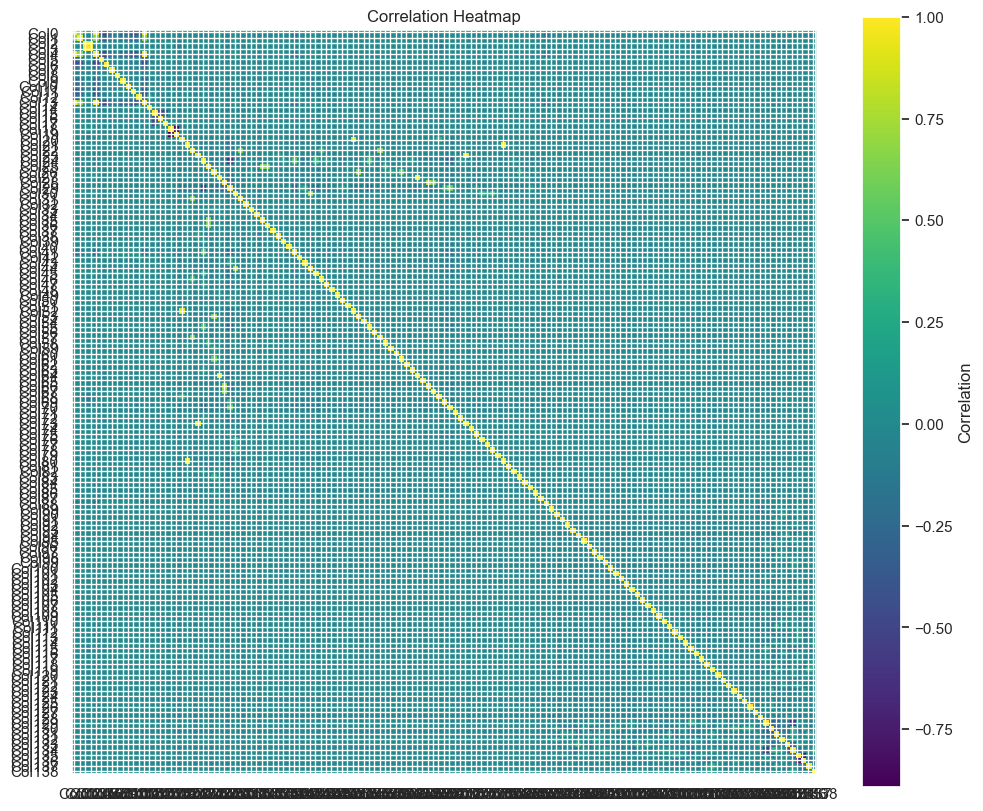

In [252]:
# Plot heatmap
plt.figure(figsize = (12,10))
plt.imshow(corr_matrix, cmap="viridis", interpolation="nearest")
plt.colorbar(label="Correlation")

# Add ticks
num_features = data_matrix1.shape[1]
plt.xticks(range(num_features), [f"Col{i}" for i in range(num_features)])
plt.yticks(range(num_features), [f"Col{i}" for i in range(num_features)])

plt.title("Correlation Heatmap")
plt.show()

In [253]:
import numpy as np
import pandas as pd

# Suppose data_matrix is (n_samples, n_features)
corr_matrix = np.corrcoef(data_matrix1, rowvar=False)

# Convert to DataFrame for readability
corr_df = pd.DataFrame(corr_matrix)

# Find correlated pairs above threshold
threshold = 0.85
high_corr = np.where(np.abs(corr_matrix) > threshold)

high_corr_pairs = [
    (i, j, corr_matrix[i, j]) 
    for i, j in zip(*high_corr) if i < j  # avoid duplicates
]

print("Highly correlated feature pairs:")
for pair in high_corr_pairs:
    print(pair)


Highly correlated feature pairs:
(np.int64(0), np.int64(4), np.float64(0.9944544649220676))
(np.int64(0), np.int64(13), np.float64(0.9944544649220676))
(np.int64(2), np.int64(3), np.float64(0.9676336575032032))
(np.int64(4), np.int64(13), np.float64(1.0))
(np.int64(18), np.int64(19), np.float64(-0.8914121600550778))
(np.int64(20), np.int64(52), np.float64(0.9300072284511858))
(np.int64(21), np.int64(80), np.float64(1.0))
(np.int64(23), np.int64(73), np.float64(0.9766333997606567))
(np.int64(27), np.int64(64), np.float64(0.985334789027332))


In [254]:


drop_cols = [0, 2 ,4, 18, 20, 21, 23, 27]

# Keep all columns except the ones in drop_cols
data_matrix_reduced = np.delete(data_matrix1, drop_cols, axis=1)

print("Original shape:", data_matrix1.shape)
print("Reduced shape:", data_matrix_reduced.shape)


Original shape: (85849, 139)
Reduced shape: (85849, 131)


In [296]:
from joblib import Parallel , delayed 
from statsmodels.stats.outliers_influence import variance_inflation_factor
df = pd.DataFrame(data_matrix1)

def compute_vif(i):
    return variance_inflation_factor(df.values,i)

vif_values = Parallel(n_jobs = -1)(delayed(compute_vif)(i) for i in range(df.shape[1]))

vif_data = pd.DataFrame({"features":df.columns , "VIF":vif_values})
print(vif_data.sort_values(by = "VIF" , ascending = False).head(10))

    features  VIF
4          4  inf
36        36  inf
35        35  inf
38        38  inf
21        21  inf
20        20  inf
23        23  inf
26        26  inf
25        25  inf
22        22  inf


In [299]:
# pd.reset_option("display.max_rows" ,None)
pd.set_option("display.max_rows" ,None)
vif_data.sort_values(by = "VIF" , ascending=False)

,features,VIF
4,4,inf
36,36,inf
35,35,inf
38,38,inf
21,21,inf
20,20,inf
23,23,inf
26,26,inf
25,25,inf
22,22,inf


In [301]:
vif_drop_col = vif_data.loc[vif_data["VIF"] > 5 , 'features'].values

In [302]:
vif_drop_col

array([  0,   2,   3,   4,   5,   6,   9,  10,  11,  12,  13,  18,  19,
        20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  33,
        34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,
        47,  48,  49,  50,  51,  52,  53,  55,  57,  58,  59,  60,  61,
        62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,
        75,  79,  80,  83,  84,  85,  86, 135, 136])

In [303]:
len(vif_drop_col)

74

In [304]:
data_matrix_reduced1 = np.delete(data_matrix1 , vif_drop_col , axis = 1)
print("Original shape:", data_matrix1.shape)
print("Reduced shape:", data_matrix_reduced1.shape)

Original shape: (85849, 139)
Reduced shape: (85849, 65)


In [305]:
data_matrix1.shape , data_matrix_reduced.shape , data_matrix_reduced1.shape

((85849, 139), (85849, 131), (85849, 65))

In [306]:
drop_cols , vif_drop_col

([0, 2, 4, 18, 20, 21, 23, 27],
 array([  0,   2,   3,   4,   5,   6,   9,  10,  11,  12,  13,  18,  19,
         20,  21,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  33,
         34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,
         47,  48,  49,  50,  51,  52,  53,  55,  57,  58,  59,  60,  61,
         62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,
         75,  79,  80,  83,  84,  85,  86, 135, 136]))

In [307]:
data_matrix_drop_cols = {"corr_drop_cols" : drop_cols ,
                         "vif_drop_cols" : vif_drop_col}


joblib.dump(data_matrix_drop_cols , f"{PREPROCESS_DIR}/data_matrix_drop_cols.joblib")


['../data_analysis1/artifacts/preprocess/data_matrix_drop_cols.joblib']

In [310]:
# np.save("../data/processed/data_matrix.npy", data_matrix)
np.save(f"{PREPROCESS_DIR}/data_matrix1.npy", data_matrix1)
# np.save("../data/processed/data_matrix2.npy", data_matrix2)
np.save(f"{PREPROCESS_DIR}/data_matrix_reduced.npy", data_matrix_reduced)
np.save(f"{PREPROCESS_DIR}/data_matrix_reduced1.npy", data_matrix_reduced1)
np.save(f"{PREPROCESS_DIR}/y.npy" , y)

### Raw data cleaning , preprocessing and scaling completed . Feature Extraction and Feature selection completed .

### Finally we have clean data matrix (data_matrix1) and target variable(y) that are model ready .


### All the necessary artifacts have been also saved.